# Import the packages

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# Import the datasets for 2024:

In [2]:
# url_2024 = "https://co2cars.apps.eea.europa.eu/tools/download?download_query=http://co2cars.apps.eea.europa.eu/?source={"track_total_hits":true,"query":{"bool":{"must":[{"constant_score":{"filter":{"bool":{"must":[{"bool":{"should":[{"term":{"year":2024}}]}},{"bool":{"should":[{"term":{"scStatus":"Final"}}]}}]}}}}]}},"display_type":"tabular"}&download_format=csv"
df_2024 = pd.read_csv("../data/raw/eu/2024.csv")

# Let's start with the obvious ones:

# we wanna filter the data for France:

In [3]:
df_fr_2024 = df_2024[df_2024["Country"] == "FR"]

display(df_fr_2024.head())


,ID,Country,VFN,Mp,Mh,Man,MMS,Tan,T,Va,Ve,Mk,Cn,Ct,Cr,r,m (kg),Mt,Enedc (g/km),Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Ernedc (g/km),Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
10817,145565889,FR,IP-MQB37WZ_A3_0570-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,NaN,E1*2007/46*2014*23,CD,ACDLAAX0,FD7FD7CW005N4BISON1VL1AVR2A00,VOLKSWAGEN,GOLF,M1,M1,1,1304.00,1432.00,NaN,118.00,petrol,H,999.00,81.00,NaN,NaN,NaN,NaN,NaN,NaN,F,2024,2024-03-18,5.20,NaN,RL-DQ200_7F_20_001-WVW-1,NaN
10818,145565888,FR,IP-0502841-NLH,HYUNDAI MOTOR EUROPE,HYUNDAI TURKIYE,HYUNDAI MOTOR TURKIYE OTOMOTIV AS,NaN,E5*2007/46*0121*06,BC3,B5P11,M51AZ1,HYUNDAI,I20,M1,M1,1,1088.00,1186.00,NaN,121.00,petrol,M,1197.00,57.00,NaN,NaN,NaN,NaN,NaN,NaN,F,2024,2024-10-22,5.30,NaN,RL-050011-NLH,NaN
10819,145565887,FR,IP-25815P118PAA_01-SAL,NaN,JAGUAR LAND ROVER LIMITED,JAGUAR LAND ROVER LIMITED,NaN,E5*2007/46*0076*12,LZ,HODEC0,50CA000,LAND ROVER,RANGE ROVER EVOQUE,M1,M1,1,2192.00,2279.00,NaN,34.00,petrol/electric,P,1498.00,118.00,196.00,NaN,NaN,NaN,NaN,NaN,F,2024,2024-12-24,1.50,NaN,RL-23PTA8G30_AA_01-SAL-1,60.00
10820,145565886,FR,IP-JFB1MTGJT4A_000-UU1-0,RENAULT-NISSAN-MITSUBISHI,DACIA,AUTOMOBILE DACIA SA,NaN,E19*2007/46*0026*20,DJF,BEV,MT6UA45M52V0,DACIA,SANDERO,M1,M1,1,1229.00,1309.00,NaN,114.00,lpg,B,999.00,67.00,NaN,e9 29 37,NaN,1.70,NaN,NaN,F,2024,2024-03-04,7.10,NaN,RL-JFAJT4A_220_000-UU1-0,NaN
10821,145565885,FR,IP-JBB1N4PDB1A_000-VF1,RENAULT-NISSAN-MITSUBISHI,RENAULT,RENAULT SAS,NaN,E2*2007/46*0684*28,RJB,HH2,N44WB22A500B,RENAULT,CAPTUR,M1,M1,1,1445.00,1570.00,NaN,106.00,petrol,H,1598.00,51.00,NaN,e9 37,NaN,1.03,NaN,NaN,F,2024,2024-09-11,4.70,NaN,RL-JBDDB1C_350_000-VF1,NaN


In [4]:
df_fr_2024.info()

<class 'pandas.DataFrame'>
Index: 1820622 entries, 10817 to 8823459
Data columns (total 37 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Country               str    
 2   VFN                   str    
 3   Mp                    str    
 4   Mh                    str    
 5   Man                   str    
 6   MMS                   float64
 7   Tan                   str    
 8   T                     str    
 9   Va                    str    
 10  Ve                    str    
 11  Mk                    str    
 12  Cn                    str    
 13  Ct                    str    
 14  Cr                    str    
 15  r                     int64  
 16  m (kg)                float64
 17  Mt                    float64
 18  Enedc (g/km)          float64
 19  Ewltp (g/km)          float64
 20  Ft                    str    
 21  Fm                    str    
 22  ec (cm3)              float64
 23  ep (KW)            

# At this point, we know all our data is for **France**. 
# We can just drop the country column.

In [5]:
df_fr_2024.drop("Country", axis = 1, inplace = True)

df_fr_2024.head()

,ID,VFN,Mp,Mh,Man,MMS,Tan,T,Va,Ve,Mk,Cn,Ct,Cr,r,m (kg),Mt,Enedc (g/km),Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Ernedc (g/km),Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
10817,145565889,IP-MQB37WZ_A3_0570-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,NaN,E1*2007/46*2014*23,CD,ACDLAAX0,FD7FD7CW005N4BISON1VL1AVR2A00,VOLKSWAGEN,GOLF,M1,M1,1,1304.00,1432.00,NaN,118.00,petrol,H,999.00,81.00,NaN,NaN,NaN,NaN,NaN,NaN,F,2024,2024-03-18,5.20,NaN,RL-DQ200_7F_20_001-WVW-1,NaN
10818,145565888,IP-0502841-NLH,HYUNDAI MOTOR EUROPE,HYUNDAI TURKIYE,HYUNDAI MOTOR TURKIYE OTOMOTIV AS,NaN,E5*2007/46*0121*06,BC3,B5P11,M51AZ1,HYUNDAI,I20,M1,M1,1,1088.00,1186.00,NaN,121.00,petrol,M,1197.00,57.00,NaN,NaN,NaN,NaN,NaN,NaN,F,2024,2024-10-22,5.30,NaN,RL-050011-NLH,NaN
10819,145565887,IP-25815P118PAA_01-SAL,NaN,JAGUAR LAND ROVER LIMITED,JAGUAR LAND ROVER LIMITED,NaN,E5*2007/46*0076*12,LZ,HODEC0,50CA000,LAND ROVER,RANGE ROVER EVOQUE,M1,M1,1,2192.00,2279.00,NaN,34.00,petrol/electric,P,1498.00,118.00,196.00,NaN,NaN,NaN,NaN,NaN,F,2024,2024-12-24,1.50,NaN,RL-23PTA8G30_AA_01-SAL-1,60.00
10820,145565886,IP-JFB1MTGJT4A_000-UU1-0,RENAULT-NISSAN-MITSUBISHI,DACIA,AUTOMOBILE DACIA SA,NaN,E19*2007/46*0026*20,DJF,BEV,MT6UA45M52V0,DACIA,SANDERO,M1,M1,1,1229.00,1309.00,NaN,114.00,lpg,B,999.00,67.00,NaN,e9 29 37,NaN,1.70,NaN,NaN,F,2024,2024-03-04,7.10,NaN,RL-JFAJT4A_220_000-UU1-0,NaN
10821,145565885,IP-JBB1N4PDB1A_000-VF1,RENAULT-NISSAN-MITSUBISHI,RENAULT,RENAULT SAS,NaN,E2*2007/46*0684*28,RJB,HH2,N44WB22A500B,RENAULT,CAPTUR,M1,M1,1,1445.00,1570.00,NaN,106.00,petrol,H,1598.00,51.00,NaN,e9 37,NaN,1.03,NaN,NaN,F,2024,2024-09-11,4.70,NaN,RL-JBDDB1C_350_000-VF1,NaN


# Same for **Status** column. 
# We know all our data is in **Final** status; hence we can just drop this column.

In [6]:
df_fr_2024.drop("Status", axis = 1, inplace = True)

df_fr_2024.head()

,ID,VFN,Mp,Mh,Man,MMS,Tan,T,Va,Ve,Mk,Cn,Ct,Cr,r,m (kg),Mt,Enedc (g/km),Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Ernedc (g/km),Erwltp (g/km),De,Vf,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
10817,145565889,IP-MQB37WZ_A3_0570-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,NaN,E1*2007/46*2014*23,CD,ACDLAAX0,FD7FD7CW005N4BISON1VL1AVR2A00,VOLKSWAGEN,GOLF,M1,M1,1,1304.00,1432.00,NaN,118.00,petrol,H,999.00,81.00,NaN,NaN,NaN,NaN,NaN,NaN,2024,2024-03-18,5.20,NaN,RL-DQ200_7F_20_001-WVW-1,NaN
10818,145565888,IP-0502841-NLH,HYUNDAI MOTOR EUROPE,HYUNDAI TURKIYE,HYUNDAI MOTOR TURKIYE OTOMOTIV AS,NaN,E5*2007/46*0121*06,BC3,B5P11,M51AZ1,HYUNDAI,I20,M1,M1,1,1088.00,1186.00,NaN,121.00,petrol,M,1197.00,57.00,NaN,NaN,NaN,NaN,NaN,NaN,2024,2024-10-22,5.30,NaN,RL-050011-NLH,NaN
10819,145565887,IP-25815P118PAA_01-SAL,NaN,JAGUAR LAND ROVER LIMITED,JAGUAR LAND ROVER LIMITED,NaN,E5*2007/46*0076*12,LZ,HODEC0,50CA000,LAND ROVER,RANGE ROVER EVOQUE,M1,M1,1,2192.00,2279.00,NaN,34.00,petrol/electric,P,1498.00,118.00,196.00,NaN,NaN,NaN,NaN,NaN,2024,2024-12-24,1.50,NaN,RL-23PTA8G30_AA_01-SAL-1,60.00
10820,145565886,IP-JFB1MTGJT4A_000-UU1-0,RENAULT-NISSAN-MITSUBISHI,DACIA,AUTOMOBILE DACIA SA,NaN,E19*2007/46*0026*20,DJF,BEV,MT6UA45M52V0,DACIA,SANDERO,M1,M1,1,1229.00,1309.00,NaN,114.00,lpg,B,999.00,67.00,NaN,e9 29 37,NaN,1.70,NaN,NaN,2024,2024-03-04,7.10,NaN,RL-JFAJT4A_220_000-UU1-0,NaN
10821,145565885,IP-JBB1N4PDB1A_000-VF1,RENAULT-NISSAN-MITSUBISHI,RENAULT,RENAULT SAS,NaN,E2*2007/46*0684*28,RJB,HH2,N44WB22A500B,RENAULT,CAPTUR,M1,M1,1,1445.00,1570.00,NaN,106.00,petrol,H,1598.00,51.00,NaN,e9 37,NaN,1.03,NaN,NaN,2024,2024-09-11,4.70,NaN,RL-JBDDB1C_350_000-VF1,NaN


# Let's see our missing data in percentages for each column now:

In [7]:
missing_info = pd.DataFrame({
    'Column': df_fr_2024.columns,
    'Missing in numbers': df_fr_2024.isna().sum().values,
    'Missing in percentage': (df_fr_2024.isna().mean() * 100).round(2).values
})

# sort by 'Missing in percentage' in descending order and reset the index
missing_info = missing_info.sort_values('Missing in percentage', ascending=False).reset_index(drop=True)

print(missing_info)

                  Column  Missing in numbers  Missing in percentage
0           Enedc (g/km)             1820622                 100.00
1                    ech             1820622                 100.00
2                     Vf             1820622                 100.00
3                     De             1820622                 100.00
4                    MMS             1820622                 100.00
5          Ernedc (g/km)             1820622                 100.00
6              z (Wh/km)             1370954                  75.30
7    Electric range (km)             1370953                  75.30
8          Erwltp (g/km)              692199                  38.02
9                     IT              692199                  38.02
10      Fuel consumption              301902                  16.58
11              ec (cm3)              301639                  16.57
12                    Mp               91995                   5.05
13                  RLFI                 175    

# We see that **De, Vf, Enedc (g/km), ech, MMS, Ernedc (g/km)** columns are 100% empty.
**De:** The reason the "De" (Deviation Factor) column is completely empty (100%) in the final 2024 dataset is a permanent structural change made by the European Environment Agency (EEA) to its database architecture and reporting strategy [Ref](https://data.europa.eu/data/datasets/5018ec17-2348-4c92-8761-6f2377bbd1c0?locale=en) 

**Vf:** The reason the "Vf" (Verification Factor) column is completely empty (100%) in the final 2024 dataset is a permanent structural change made by the European Environment Agency (EEA) to its database architecture and reporting strategy  [Ref](https://sdi.eea.europa.eu/catalogue/api/records/5018ec17-2348-4c92-8761-6f2377bbd1c0/attachments/Table-definition-cars-2024-Final.xlsx).

**Enedc (g/km):** The reason the "Enedc (g/km)" column is completely empty (Null/NaN) in 2024 dataset is that the European Union has officially phased out the old NEDC testing standard entirely.  [Ref](https://data.europa.eu/data/datasets/5018ec17-2348-4c92-8761-6f2377bbd1c0?locale=en) 

**ech:** Preliminary reviews have revealed that in the EEA’s finalized 2024 dataset, sub-breakdown parameters such as ech (High-Speed Electricity Consumption) are 100% empty (NaN). In contrast, it was observed that the data architecture was modified in the 2025 provisional dataset, the ech column was integrated into the system as a float64 type, and a meaningful 27% fill rate was achieved for electric vehicles. However, due to administrative/validation deficiencies in the 2025 data (the MMS, Vf, and De columns being empty), the study opted to perform robust modeling using the main “ec” (average electricity consumption) variable from the 2024 dataset rather than the sub-categories.

**MMS:** The EEA already automatically processes producer names into the Mh (Standardized Main Producer Name) column in a cleaned format to improve data quality. Since this standardization is performed in the provisional versions, there is no need for raw member country records (MMS).  [Ref](https://data.europa.eu/data/datasets/5018ec17-2348-4c92-8761-6f2377bbd1c0?locale=en) 

**Ernedc (g/km):** The reason the "Enedc (g/km)" column is completely empty (Null/NaN) in 2024 dataset is that the European Union has officially phased out the old NEDC testing standard entirely.  [Ref](https://data.europa.eu/data/datasets/5018ec17-2348-4c92-8761-6f2377bbd1c0?locale=en) 

# Hence, we can drop these fields from our table.



In [8]:
df_fr_2024.drop(['De', 'Vf', 'Enedc (g/km)', 'ech', 'MMS', 'Ernedc (g/km)'], axis = 1, inplace = True)

df_fr_2024.head()

,ID,VFN,Mp,Mh,Man,Tan,T,Va,Ve,Mk,Cn,Ct,Cr,r,m (kg),Mt,Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Erwltp (g/km),year,Date of registration,Fuel consumption,RLFI,Electric range (km)
10817,145565889,IP-MQB37WZ_A3_0570-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,E1*2007/46*2014*23,CD,ACDLAAX0,FD7FD7CW005N4BISON1VL1AVR2A00,VOLKSWAGEN,GOLF,M1,M1,1,1304.00,1432.00,118.00,petrol,H,999.00,81.00,NaN,NaN,NaN,2024,2024-03-18,5.20,RL-DQ200_7F_20_001-WVW-1,NaN
10818,145565888,IP-0502841-NLH,HYUNDAI MOTOR EUROPE,HYUNDAI TURKIYE,HYUNDAI MOTOR TURKIYE OTOMOTIV AS,E5*2007/46*0121*06,BC3,B5P11,M51AZ1,HYUNDAI,I20,M1,M1,1,1088.00,1186.00,121.00,petrol,M,1197.00,57.00,NaN,NaN,NaN,2024,2024-10-22,5.30,RL-050011-NLH,NaN
10819,145565887,IP-25815P118PAA_01-SAL,NaN,JAGUAR LAND ROVER LIMITED,JAGUAR LAND ROVER LIMITED,E5*2007/46*0076*12,LZ,HODEC0,50CA000,LAND ROVER,RANGE ROVER EVOQUE,M1,M1,1,2192.00,2279.00,34.00,petrol/electric,P,1498.00,118.00,196.00,NaN,NaN,2024,2024-12-24,1.50,RL-23PTA8G30_AA_01-SAL-1,60.00
10820,145565886,IP-JFB1MTGJT4A_000-UU1-0,RENAULT-NISSAN-MITSUBISHI,DACIA,AUTOMOBILE DACIA SA,E19*2007/46*0026*20,DJF,BEV,MT6UA45M52V0,DACIA,SANDERO,M1,M1,1,1229.00,1309.00,114.00,lpg,B,999.00,67.00,NaN,e9 29 37,1.70,2024,2024-03-04,7.10,RL-JFAJT4A_220_000-UU1-0,NaN
10821,145565885,IP-JBB1N4PDB1A_000-VF1,RENAULT-NISSAN-MITSUBISHI,RENAULT,RENAULT SAS,E2*2007/46*0684*28,RJB,HH2,N44WB22A500B,RENAULT,CAPTUR,M1,M1,1,1445.00,1570.00,106.00,petrol,H,1598.00,51.00,NaN,e9 37,1.03,2024,2024-09-11,4.70,RL-JBDDB1C_350_000-VF1,NaN


## Let's check the missing data once more now:

In [9]:
missing_info = pd.DataFrame({
    'Column': df_fr_2024.columns,
    'Missing in numbers': df_fr_2024.isna().sum().values,
    'Missing in percentage': (df_fr_2024.isna().mean() * 100).round(2).values
})

# sort by 'Missing in percentage' in descending order and reset the index
missing_info = missing_info.sort_values('Missing in percentage', ascending=False).reset_index(drop=True)

print(missing_info)

                  Column  Missing in numbers  Missing in percentage
0    Electric range (km)             1370953                  75.30
1              z (Wh/km)             1370954                  75.30
2          Erwltp (g/km)              692199                  38.02
3                     IT              692199                  38.02
4       Fuel consumption              301902                  16.58
5               ec (cm3)              301639                  16.57
6                     Mp               91995                   5.05
7                   RLFI                 175                   0.01
8                     Mt                   0                   0.00
9   Date of registration                   0                   0.00
10                  year                   0                   0.00
11               ep (KW)                   0                   0.00
12                    Fm                   0                   0.00
13                    Ft                   0    

## It seems we have 75.30% missing data for **"Electric range (km)"** & **"z (Wh/km)"** which fields looks quite high.

**"Electric range (km)":** the maximum distance the vehicle can travel using only the electrical energy stored in its battery without consuming any fuel (zero emissions)
**"z (Wh/km)":** Electric energy consumption.

## However, our dataset contains **Fossil fuel cars, Hybrid cars, electric cars as much as other fuel types**. 
## Let's see if we can justify these numbers:

## Let's see the distribution of **Ft** field, which stands for fuel type:

Total Number of Unique Values in Column Ft: 10
                Ft  percentage
0           petrol       61.98
1         electric       16.54
2           diesel        8.60
3  petrol/electric        7.77
4              lpg        3.19
5              e85        1.48
6  diesel/electric        0.39
7         hydrogen        0.03
8               ng        0.01


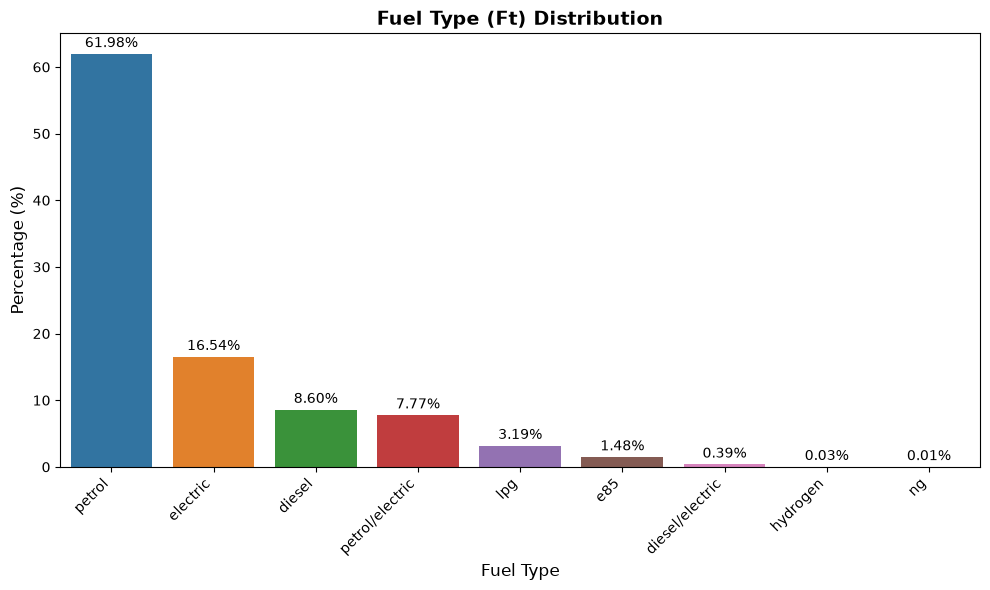

In [10]:
# 1. Get the total number of unique Fuel type categories in the Ft column
print(f"Total Number of Unique Values in Column Ft: {df_2024['Ft'].nunique()}")

# 2. View the complete distribution of entered categories and their frequencies
ft_pct = (
    df_fr_2024["Ft"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)
ft_pct.columns = ["Ft", "percentage"]
print(ft_pct)

# Graph
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(data=ft_pct, x="Ft", y="percentage", ax=ax, hue = "Ft", legend = False)

ax.set_title("Fuel Type (Ft) Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Fuel Type", fontsize=12)
ax.set_ylabel("Percentage (%)", fontsize=12)

plt.xticks(rotation=45, ha="right")

# Write the percentage value above each bar
for i, row in ft_pct.iterrows():
    ax.text(i, row["percentage"] + 0.5, f"{row['percentage']:.2f}%", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


- **petrol cars** account for **61,98%**
- **diesel cars** account for **8,60%**
- **lpg cars** account for **3,19%**
- **e85** cars account for **1.48%**
- **hydrogen** cars account for **0,03**
- **ng cars** account for **0,01%**
None of these cars will have an electric range since they are not electric cars, so let's sum up these numbers:
61,98+8,6+3,19+1,48+0,03+0,01 = 75,29%
### That's the exact percentage of missing fields for **"Electric range (km)" & "z (Wh/km)"** columns (75,30%).


# Next, we see that **Erwltp (g/km)** and **IT** columns having **38.02%** missing data.
**Erwltp (g/km):** Emissions reduction through innovative technologies (WLTP).

**IT:** Innovative technology or group of innovative technologies.
- ### Both of these columns are related to **vehicles that actually emit Co2**, so the vehicles that have **0** emission should not have values in that column.
- ### Also, there might be vehicles that don't use any technologies to reduce the Co2 emission, so those lines would also be empty.

In [11]:
df = df_fr_2024[df_fr_2024["Erwltp (g/km)"].isna() == True]

ft_pct = (
    df["Ft"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)
ft_pct.columns = ["Ft", "percentage"]
print("Distribution of fuel type (FT) in data where Erwltp (g/km) is '0'\n")
print(ft_pct)

Distribution of fuel type (FT) in data where Erwltp (g/km) is '0'

                Ft  percentage
0         electric       43.50
1           petrol       30.47
2  petrol/electric       20.45
3           diesel        3.25
4              e85        1.20
5  diesel/electric        1.01
6         hydrogen        0.08
7               ng        0.04
8              lpg        0.00


Since the **Erwltp (g/km)** and **IT** columns pertain to innovative emission-reducing technologies, it is to be expected that these fields will be blank for electric and hydrogen-powered vehicles with zero exhaust emissions. 
When examining the fuel type distribution of records in the dataset that are missing an **Erwltp (g/km)** value, it is observed that **43.5%** of these records are for **fully electric vehicles** and **0.08%** are for **hydrogen-powered** vehicles. 
The remainder consists of **gasoline, diesel, E85,** and other fuel types; this indicates that the missing values stem not only from **“not applicable”** cases but also from the **“absence of innovative technology”** or **“data gaps.”** 

Therefore, rather than filling in the missing data in these columns with a single strategy, it would be more meaningful to use different approaches based on **fuel type** and **vehicle technology** (e.g., **“not applicable”** for electric vehicles, **“no innovative tech”** for emission-producing vehicles, or statistical imputation).

## Next, we see that **ec (cm3)** and **Fuel consumption** columns have **16.57%** and **16.58%** missing data respectively.
**ec (cm3):** Engine capacity.

**Fuel consumption:** Fuel consumption.
### Logically, we know that the electric cars, don't have fuel consumption, and hence they don't have a measurable engine capacity. 
### Let's see if we can justify these numbers:

In [12]:
df_fc = df_fr_2024[df_fr_2024["Fuel consumption"].isna() == True]
display(df_fc["Ft"].value_counts())
# We see that in absence of fuel consumption, there is no lines with fuel cars (petrol, diesel, electric/petrol, electric/diesel)

# Let's see the number of electric cars with no engine capacity
display(df_fc[df_fc["Ft"] == "electric"]["ec (cm3)"].value_counts())
# we see that electric cars have no engine capacity (as expected)

print("/n")
# Let's now see the numbers of engine capacity for the hydrogen and ng cars
display(df_fc[df_fc["Ft"].isin(["hydrogen", "ng"])]["ec (cm3)"].value_counts())

print("/n")
# Let's now check if there are any fuel cars with missing engine capacity
df_ec = df_fr_2024[df_fr_2024["ec (cm3)"].isna() == True]
display(df_ec["Ft"].value_counts())

Ft
electric    301108
hydrogen       531
ng             263
Name: count, dtype: int64

Series([], Name: count, dtype: int64)

/n


ec (cm3)
999.00     256
1498.00      7
Name: count, dtype: int64

/n


Ft
electric    301108
hydrogen       531
Name: count, dtype: int64

In [13]:
# Engine Capacity Distribution of Hydrogen and Natural Gas Vehicles
df_fr_2024[df_fr_2024["Ft"].isin(["hydrogen", "ng"])]["ec (cm3)"].describe()

# Fuel Consumption Breakdown for Hydrogen and Natural Gas Vehicles
df_fr_2024[df_fr_2024["Ft"].isin(["hydrogen", "ng"])]["Fuel consumption"].describe()

# Missing Rates for All Vehicle Types
df_fr_2024[["Ft", "Fuel consumption", "ec (cm3)"]].groupby("Ft").apply(
    lambda x: x.isna().mean() * 100
)

,Fuel consumption,ec (cm3)
Ft,,
diesel,0.00,0.00
diesel/electric,0.00,0.00
e85,0.00,0.00
electric,100.00,100.00
hydrogen,100.00,100.00
lpg,0.00,0.00
ng,100.00,0.00
petrol,0.00,0.00
petrol/electric,0.00,0.00


## Electric and hydrogen vehicles:
- There is a 100% discrepancy in both categories, which is entirely expected.
- Electric vehicles have neither fuel consumption nor engine capacity.
- Hydrogen vehicles likely use different metrics as well (e.g., kg H₂/100 km).

## Natural gas (ng) vehicles:
- **Fuel consumption:** 100% missing—these vehicles likely use a different metric, such as “gas consumption.”
- **ec (cm³):** 0% missing—meaning engine capacity data is available for all natural gas vehicles. This makes sense, since natural gas vehicles typically use modified internal combustion engines.

## At this moment we can stop and think, should we have the vehichle types that have **zero emission** in our study?
## Let's see the fuel types of the entries that has **0** in **"Ewltp (g/km)"** values.

In [14]:
df_no_target = df_fr_2024[df_fr_2024["Ewltp (g/km)"] == 0]

display(df_no_target["Ft"].value_counts())

Ft
electric    301108
hydrogen       531
Name: count, dtype: int64

## Okay, this tells us we can drop the **electric & hydrogen** cars from our study, since they don't really emit co2.

In [15]:
# filter out Electric & hydrogen cars
df_fr_2024 = df_fr_2024[~df_fr_2024["Ft"].isin(["electric", "hydrogen"])]

In [16]:
display(df_fr_2024.describe())
display(df_fr_2024.info())
df_fr_2024.head()

,ID,r,m (kg),Mt,Ewltp (g/km),ec (cm3),ep (KW),z (Wh/km),Erwltp (g/km),year,Fuel consumption,Electric range (km)
count,1518983.00,1518983.00,1518983.00,1518983.00,1518983.00,1518983.00,1518983.00,148560.00,1128423.00,1518983.00,1518720.00,148561.00
mean,145976171.71,1.00,1426.24,1538.72,112.81,1401.58,89.35,196.87,1.43,2024.00,4.99,75.51
std,525663.62,0.00,302.67,320.00,32.72,400.55,37.73,42.50,0.54,0.00,1.47,24.68
min,145065870.00,1.00,570.00,616.00,6.00,658.00,4.00,101.00,0.50,2024.00,0.30,11.00
25%,145520793.00,1.00,1203.00,1307.00,106.00,1197.00,67.00,169.00,0.90,2024.00,4.70,57.00
50%,145976326.00,1.00,1355.00,1460.00,120.00,1332.00,81.00,182.00,1.63,2024.00,5.30,68.00
75%,146431400.50,1.00,1585.00,1704.00,129.00,1598.00,110.00,215.00,1.91,2024.00,5.70,85.00
max,146886490.00,1.00,2815.00,3150.00,456.00,6749.00,614.00,372.00,2.78,2024.00,20.10,702.00


<class 'pandas.DataFrame'>
Index: 1518983 entries, 10817 to 8823459
Data columns (total 29 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   ID                    1518983 non-null  int64  
 1   VFN                   1518983 non-null  str    
 2   Mp                    1485527 non-null  str    
 3   Mh                    1518983 non-null  str    
 4   Man                   1518983 non-null  str    
 5   Tan                   1518983 non-null  str    
 6   T                     1518983 non-null  str    
 7   Va                    1518982 non-null  str    
 8   Ve                    1518981 non-null  str    
 9   Mk                    1518983 non-null  str    
 10  Cn                    1518983 non-null  str    
 11  Ct                    1518983 non-null  str    
 12  Cr                    1518983 non-null  str    
 13  r                     1518983 non-null  int64  
 14  m (kg)                1518983 non-null  float6

None

,ID,VFN,Mp,Mh,Man,Tan,T,Va,Ve,Mk,Cn,Ct,Cr,r,m (kg),Mt,Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Erwltp (g/km),year,Date of registration,Fuel consumption,RLFI,Electric range (km)
10817,145565889,IP-MQB37WZ_A3_0570-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,E1*2007/46*2014*23,CD,ACDLAAX0,FD7FD7CW005N4BISON1VL1AVR2A00,VOLKSWAGEN,GOLF,M1,M1,1,1304.00,1432.00,118.00,petrol,H,999.00,81.00,NaN,NaN,NaN,2024,2024-03-18,5.20,RL-DQ200_7F_20_001-WVW-1,NaN
10818,145565888,IP-0502841-NLH,HYUNDAI MOTOR EUROPE,HYUNDAI TURKIYE,HYUNDAI MOTOR TURKIYE OTOMOTIV AS,E5*2007/46*0121*06,BC3,B5P11,M51AZ1,HYUNDAI,I20,M1,M1,1,1088.00,1186.00,121.00,petrol,M,1197.00,57.00,NaN,NaN,NaN,2024,2024-10-22,5.30,RL-050011-NLH,NaN
10819,145565887,IP-25815P118PAA_01-SAL,NaN,JAGUAR LAND ROVER LIMITED,JAGUAR LAND ROVER LIMITED,E5*2007/46*0076*12,LZ,HODEC0,50CA000,LAND ROVER,RANGE ROVER EVOQUE,M1,M1,1,2192.00,2279.00,34.00,petrol/electric,P,1498.00,118.00,196.00,NaN,NaN,2024,2024-12-24,1.50,RL-23PTA8G30_AA_01-SAL-1,60.00
10820,145565886,IP-JFB1MTGJT4A_000-UU1-0,RENAULT-NISSAN-MITSUBISHI,DACIA,AUTOMOBILE DACIA SA,E19*2007/46*0026*20,DJF,BEV,MT6UA45M52V0,DACIA,SANDERO,M1,M1,1,1229.00,1309.00,114.00,lpg,B,999.00,67.00,NaN,e9 29 37,1.70,2024,2024-03-04,7.10,RL-JFAJT4A_220_000-UU1-0,NaN
10821,145565885,IP-JBB1N4PDB1A_000-VF1,RENAULT-NISSAN-MITSUBISHI,RENAULT,RENAULT SAS,E2*2007/46*0684*28,RJB,HH2,N44WB22A500B,RENAULT,CAPTUR,M1,M1,1,1445.00,1570.00,106.00,petrol,H,1598.00,51.00,NaN,e9 37,1.03,2024,2024-09-11,4.70,RL-JBDDB1C_350_000-VF1,NaN


## **year** column is also unified in our dataset, which is 2024; so we can also drop this column:

In [17]:
df_fr_2024.drop("year", inplace = True, axis = 1)
df_fr_2024.head()

,ID,VFN,Mp,Mh,Man,Tan,T,Va,Ve,Mk,Cn,Ct,Cr,r,m (kg),Mt,Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Erwltp (g/km),Date of registration,Fuel consumption,RLFI,Electric range (km)
10817,145565889,IP-MQB37WZ_A3_0570-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,E1*2007/46*2014*23,CD,ACDLAAX0,FD7FD7CW005N4BISON1VL1AVR2A00,VOLKSWAGEN,GOLF,M1,M1,1,1304.00,1432.00,118.00,petrol,H,999.00,81.00,NaN,NaN,NaN,2024-03-18,5.20,RL-DQ200_7F_20_001-WVW-1,NaN
10818,145565888,IP-0502841-NLH,HYUNDAI MOTOR EUROPE,HYUNDAI TURKIYE,HYUNDAI MOTOR TURKIYE OTOMOTIV AS,E5*2007/46*0121*06,BC3,B5P11,M51AZ1,HYUNDAI,I20,M1,M1,1,1088.00,1186.00,121.00,petrol,M,1197.00,57.00,NaN,NaN,NaN,2024-10-22,5.30,RL-050011-NLH,NaN
10819,145565887,IP-25815P118PAA_01-SAL,NaN,JAGUAR LAND ROVER LIMITED,JAGUAR LAND ROVER LIMITED,E5*2007/46*0076*12,LZ,HODEC0,50CA000,LAND ROVER,RANGE ROVER EVOQUE,M1,M1,1,2192.00,2279.00,34.00,petrol/electric,P,1498.00,118.00,196.00,NaN,NaN,2024-12-24,1.50,RL-23PTA8G30_AA_01-SAL-1,60.00
10820,145565886,IP-JFB1MTGJT4A_000-UU1-0,RENAULT-NISSAN-MITSUBISHI,DACIA,AUTOMOBILE DACIA SA,E19*2007/46*0026*20,DJF,BEV,MT6UA45M52V0,DACIA,SANDERO,M1,M1,1,1229.00,1309.00,114.00,lpg,B,999.00,67.00,NaN,e9 29 37,1.70,2024-03-04,7.10,RL-JFAJT4A_220_000-UU1-0,NaN
10821,145565885,IP-JBB1N4PDB1A_000-VF1,RENAULT-NISSAN-MITSUBISHI,RENAULT,RENAULT SAS,E2*2007/46*0684*28,RJB,HH2,N44WB22A500B,RENAULT,CAPTUR,M1,M1,1,1445.00,1570.00,106.00,petrol,H,1598.00,51.00,NaN,e9 37,1.03,2024-09-11,4.70,RL-JBDDB1C_350_000-VF1,NaN


# Now let's check **VFN** column:
**VFN:** Vehicle family identification number.


In [18]:
print(df_fr_2024["VFN"].describe())

count                    1518983
unique                      2315
top       IP-JAA1MTPJT4A_000-VF1
freq                       48040
Name: VFN, dtype: object


# Old Format:
# IP-TA-WMI-yyyy-nnnn

**IP:** Abbreviation for the Interpolation Family. 

**TA:** Type Approval Authority (e.g., E1 for Germany, E2 for France).

**WMI:** World Manufacturer Identifier (ISO standard manufacturer code). 

**yyyy:** Year of approval. 

**nnnn:** 4-digit family number.

# New Format:
# **The Updated Reference Format:** 24-Character Standard For newer vehicle allocations, the mandate shifted. 
As published in [Commission Regulation (EU) 2017/1151 (Annex XXI)](https://www.legislation.gov.uk/eur/2017/1151/annex/XXI/division/5/adopted) and mirrored across regional compliance portals, vehicles approved starting January 1, 2018 (and strictly enforced from 2019 onward) migrated to an altered 24-character continuous format:

# IP-nnnnnnnnnnnnnnn-WMI-x

**IP:** The static Interpolation Family code designation.

**nnnnnnnnnnnnnnn:** A customized alphanumeric string up to 15 characters long (using 0-9, A-Z, or underscores) defined by the manufacturer.

**WMI:** The 3-character World Manufacturer Identifier.

**x:** A final component identifier variable.


### Let's see the pattern of our data:

In [19]:
parts = df_fr_2024["VFN"].str.split("-", expand=True)
parts.columns = [f"p{i}" for i in range(parts.shape[1])]

starts_IP = parts["p0"] == "IP"

# regex checks
def mid_ok(s):
    return s.str.match(r"^[0-9A-Za-z_]{1,25}$", na=False)

def wmi_ok(s):
    return s.str.match(r"^[A-Z0-9]{2,4}$", na=False)

def x_ok(s):
    return s.str.match(r"^[A-Z0-9]{1,2}$", na=False)

def sub_ok(s):
    return s.str.match(r"^[0-9A-Za-z]{1,4}$", na=False)

# 3 parts: IP - mid - WMI
has_3 = (parts.shape[1] >= 3) & parts.iloc[:, :3].notna().all(axis=1)
valid_3 = (
    starts_IP & has_3 &
    mid_ok(parts["p1"]) &
    wmi_ok(parts["p2"])
)

# 4 parts: IP - mid - WMI - x
has_4 = (parts.shape[1] >= 4) & parts.iloc[:, :4].notna().all(axis=1)
valid_4 = (
    starts_IP & has_4 &
    mid_ok(parts["p1"]) &
    wmi_ok(parts["p2"]) &
    x_ok(parts["p3"])
)

# 5 parts: IP - sub - mid - WMI - x
has_5 = (parts.shape[1] >= 5) & parts.iloc[:, :5].notna().all(axis=1)
valid_5 = (
    starts_IP & has_5 &
    sub_ok(parts["p1"]) &
    mid_ok(parts["p2"]) &
    wmi_ok(parts["p3"]) &
    x_ok(parts["p4"])
)

valid_new = valid_3 | valid_4 | valid_5

# Old format: IP-TA-WMI-yyyy-nnnn
pattern_old = r"^(IP)-([A-Z0-9]{1,3})-([A-Z0-9]{1,5})-(\d{4})-([A-Z0-9]{1,6})$"
old_fmt = df_fr_2024["VFN"].str.extract(pattern_old)
old_fmt.columns = ["IP", "TA", "WMI_old", "yyyy", "nnnn"]
old_valid = old_fmt.notna().all(axis=1)

# Summary
summary = pd.Series({
    "total_rows": len(df_fr_2024),
    "valid_new_format": valid_new.sum(),
    "valid_old_format": old_valid.sum(),
    "invalid_any_format": (~ (valid_new | old_valid)).sum(),
})

print(summary)

# Invalid entries:
invalid_mask = ~ (valid_new | old_valid)
df_invalid = df_fr_2024[invalid_mask].copy()

# Valid entries:
df_valid = df_fr_2024[~invalid_mask].copy()

display("Invalid entries:", df_invalid.VFN)

total_rows            1518983
valid_new_format      1518982
valid_old_format           71
invalid_any_format          1
dtype: int64


'Invalid entries:'

1634649    IP - 0015 - ZHW-1
Name: VFN, dtype: str

**IP (Interpolation Family Identifier)**
* **What it means:** A constant string indicating that this vehicle belongs to a WLTP Interpolation Family.
* **ML Decision:** Drop. It provides zero variance (it is the same for every valid VFN).

**nnnnnnnnnnnnnnn (The Core Matrix Number)**
* **What it means:** A unique 15-character code assigned by the manufacturer. It represents a precise mathematical envelope of vehicles that share the exact same aerodynamic chassis family, engine block family, and transmission type.
* **The Catch for ML:** This is an arbitrary internal code chosen by the manufacturer (e.g., VW might use 00234A, while Renault uses REN_M1_04). The characters themselves do not have a universal physical meaning (like "digit 3 equals 4 cylinders").
* **Data Overlap:** The engine size (ec), power (ep), mass (m), and fuel type (Ft) are already explicitly given in the other columns.

**WMI (World Manufacturer Identifier)**
* **What it means:** A 3-character code identifying the manufacturing company and region (e.g., VF1 for Renault, WBA for BMW).
* **Data Overlap:** This is completely redundant with Man (Manufacturer name string), MMS (Manufacturer pool), and Mk (Make) columns.
**x (Control/Extension Digit)**
* **What it means:** A technical suffix or check digit used by type-approval authorities.
* **ML Decision:** Drop. It contains no physical information about the vehicle.


# We will drop **VFN** column.

## Let's check the data in **Mp** column:
**Mp:** Manufacturer pooling. Indicates which official emissions consortium the vehicle manufacturer belongs to.

                           Mp  percentage
0   RENAULT-NISSAN-MITSUBISHI       29.01
1                  STELLANTIS       26.45
2                  VOLKSWAGEN       15.87
3         SUBARU-MAZDA-TOYOTA       10.00
4                         BMW        4.32
5            MERCEDES-BENZ AG        3.17
6        HYUNDAI MOTOR EUROPE        2.93
7                        FORD        2.86
8                         KIA        2.84
9  VOLVO CARS POLESTAR SUZUKI        2.54


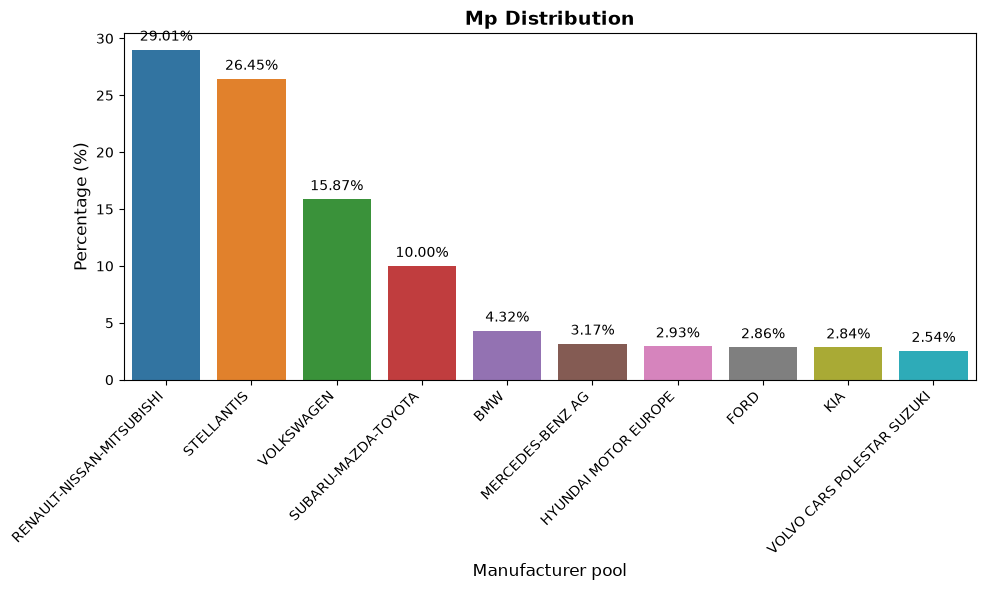

In [20]:
mp_pct = (
    df_fr_2024["Mp"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)
mp_pct.columns = ["Mp", "percentage"]
print(mp_pct)

# Graph
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(data=mp_pct, x="Mp", y="percentage", ax=ax, hue = "Mp", legend = False)

ax.set_title("Mp Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Manufacturer pool", fontsize=12)
ax.set_ylabel("Percentage (%)", fontsize=12)

plt.xticks(rotation=45, ha="right")

# Write the percentage value above each bar
for i, row in mp_pct.iterrows():
    ax.text(i, row["percentage"] + 0.5, f"{row['percentage']:.2f}%", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

# Mp columns doesn't contribute to the Co2 emission study, so we will drop it.

## Let's check the data in **Mh** column:
**Mh:** Manufacturer name EU standard denomination.

In [21]:
mh_pct = (
    df_fr_2024["Mh"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)
mh_pct.columns = ["Mh", "percentage"]
print(mh_pct.head(20))

                          Mh  percentage
0            STELLANTIS AUTO       17.98
1                    RENAULT       17.89
2                      DACIA        8.28
3                 VOLKSWAGEN        7.19
4   TOYOTA MOTOR CORPORATION        4.82
5                     TOYOTA        4.37
6        AUTOMOBILES CITROEN        4.27
7                     BMW AG        4.16
8           MERCEDES-BENZ AG        3.10
9                    AUDI AG        2.86
10           FORD WERKE GMBH        2.79
11                     SKODA        2.68
12                      SEAT        2.43
13  NISSAN AUTOMOTIVE EUROPE        1.86
14       AUTOMOBILES PEUGEOT        1.46
15                       KIA        1.45
16              KIA SLOVAKIA        1.33
17         STELLANTIS EUROPE        1.29
18             HYUNDAI CZECH        1.17
19  SUZUKI MOTOR CORPORATION        1.08


## Let's check the data in **Man** column:
**Man:** Manufacturer name OEM declaration. It is the raw name used by the manufacturer in the vehicle’s first official documents issued by the factory (e.g., Bayerische Motoren Werke AG).


In [22]:
man_pct = (
    df_fr_2024["Man"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)
man_pct.columns = ["Man", "percentage"]
print(man_pct.head(20))

                                      Man  percentage
0                     STELLANTIS AUTO SAS       17.98
1                             RENAULT SAS       17.89
2                     AUTOMOBILE DACIA SA        8.28
3                           VOLKSWAGEN AG        7.19
4                TOYOTA MOTOR CORPORATION        4.82
5               TOYOTA MOTOR EUROPE NV SA        4.37
6                     AUTOMOBILES CITROEN        4.27
7             BAYERISCHE MOTOREN WERKE AG        4.16
8                        MERCEDES-BENZ AG        3.10
9                                 AUDI AG        2.86
10                        FORD-WERKE GMBH        2.79
11                          SKODA AUTO AS        2.68
12                                SEAT SA        2.43
13           NISSAN AUTOMOTIVE EUROPE SAS        1.86
14                    AUTOMOBILES PEUGEOT        1.47
15                        KIA CORPORATION        1.45
16                       KIA SLOVAKIA SRO        1.33
17                  STELLANT

## Let's check the data in **Tan** column:
**Tan:** Type approval number.
According to official EU regulations (Directive 2007/46/EC and the current Regulation (EU) 2018/858), a complete type-approval number consists of 4 or 5 parts separated by asterisks (*)

**Format:** 𝐞𝐗 * 𝐲𝐲𝐲𝐲/𝐧𝐧𝐧𝐧 * 𝐘𝐘𝐘𝐘/𝐍𝐍𝐍𝐍 * 𝐧𝐧𝐧𝐧 * 𝐧𝐧


**Country Code (e.g., e1\*, e4\*, e13\*):** A lowercase "e" followed by the code of the EU member state that issued the approval. e1: Germany, e2: France, e3: Italy, e4: Netherlands, e6: Belgium, e11: United Kingdom, etc. 
Basic Directive/Regulation (e.g., 2007/46* or 2018/858*): Indicates the general EU framework law under which the vehicle was approved.

**Amendment/Update Regulation (Optional—e.g., 2015/166\*):** The number of the most recent legislation updating the base regulation. May not always be present. 

**Basic Approval Number (e.g., 0282\* or 0004\*):** A 4- or 5-digit sequential unique number assigned to that vehicle type by the relevant authority. 
Extension/Revision Number (e.g., 00 or 02): A 2-digit revision number that tracks minor technical updates made to the vehicle (facelifts, minor engine updates, etc.).

https://circabc.europa.eu/sd/a/d9cff59f-5117-48f4-9a37-07b94027110c/MS%20Guidelines%202019

In [23]:
tan_pct = (
    df_fr_2024["Tan"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)
tan_pct.columns = ["Tan", "percentage"]
print(tan_pct.head(20))

                     Tan  percentage
0     E2*2007/46*0003*74        2.98
1    E19*2007/46*0026*23        2.46
2     E2*2007/46*0639*32        2.11
3     E2*2007/46*0639*28        2.04
4     E2*2007/46*0676*28        1.96
5    E19*2007/46*0026*21        1.73
6     E2*2007/46*0676*24        1.51
7    E2*2001/116*0323*75        1.44
8   E6*2018/858*00013*04        1.41
9    E19*2007/46*0026*25        1.40
10    E2*2007/46*0639*31        1.38
11    E2*2007/46*0676*23        1.34
12    E1*2007/46*1783*40        1.26
13    E2*2007/46*0684*24        1.14
14    E2*2007/46*0639*30        1.12
15    E2*2007/46*0676*25        1.10
16    E2*2007/46*0639*33        1.07
17    E2*2007/46*0534*27        1.03
18    E6*2007/46*0437*07        0.98
19   E19*2007/46*0026*22        0.93


In [24]:
# TAN regex structure compliant with official EU standards (supports 4- or 5-part structures)
# Description: 
# The regex includes ALL official exceptions under EU standards (KS, NIV, IVA, 2-digit years)
# Updates made:
# (?i)                  -> Case-insensitive
# [A-Z]{0,3}\d{2,4}/    -> Allows the year portion to be 2 digits (e.g., 98/14) and to start with letters such as 'KS'
# (?:E\d{1,3}\*NIV|IVA|IV) -> Directly accepts single/special validations (E1*NIV, IVA, IV)
std_4_or_5_parts = r"e\d{1,3}\*(?:[A-Z]{1,3})?\d{2,4}/\d{2,4}\*(?:(?:[A-Z]{1,3})?\d{2,4}/\d{2,4}\*)?\d{4,6}\*\d{2,3}"
national_hybrid  = r"(?:e\d{1,3}\*)?(?:NIV|IV|NKS)(?:\*[0-9/]+|[0-9/]*)(?:[\*-]?[A-Z0-9\s-]*)?"
single_approvals = r"IVA|IV"

tan_regex = f"(?i)^\\s*(?:{std_4_or_5_parts}|{national_hybrid}|{single_approvals})\\s*$"


# Data in the correct format
tan_correct = df_fr_2024[df_fr_2024["Tan"].str.match(tan_regex, na=False)]

# Data in an incorrect or corrupted format
tan_corrupt = df_fr_2024[~df_fr_2024["Tan"].str.match(tan_regex, na=False) & df_fr_2024["Tan"].notna()]

print(f"Correct Tan rows: {len(tan_correct)}")
print(f"Corrupt Tan rows: {len(tan_corrupt)}")

Correct Tan rows: 1518983
Corrupt Tan rows: 0


## Good news, **Tan** column doesn't contain corrup data.
## Let's check the data in **T** column:
**T:** The official chassis, platform, and body architecture code registered by the manufacturer with the European Union.
According to official EU emissions regulations and manufacturer type-approval rules, the **"T"** column is an alphanumeric code determined entirely by the manufacturer.


In [25]:
# 1. Let's see the number of unique values in column T
print(f"Total Number of Unique Values in Column T: {df_2024['T'].nunique()}")

# 2. Let's take a look at the top 20 most frequently entered vehicle types
patterns_t = df_fr_2024["T"].value_counts().head(20)
print("\nTop 20 Most Frequently Entered Vehicle Types (T):")
print(patterns_t)

# 3. First-character distribution to detect manual input errors (spaces, special characters)
first_chars_t = df_fr_2024["T"].str.extract(r"^(.)").dropna().iloc[:, 0].value_counts().head(10)
print("\nInitial Character Distribution (Are there any spaces or strange characters?):")
print(first_chars_t)

Total Number of Unique Values in Column T: 1850

Top 20 Most Frequently Entered Vehicle Types (T):
T
U              147706
DJF            125830
RJA            107890
RJB             56526
F               54962
S               47742
RHN             43300
XPA1F(EU,M)     38325
XPB1F(M)        34606
AW              26820
K               22812
SRD             22105
M               21500
J2K             20706
RJL             19424
CD              19086
KJ              18417
A1              17708
NX4E            16881
2               16688
Name: count, dtype: int64

Initial Character Distribution (Are there any spaces or strange characters?):
0
R    256196
U    183358
D    146056
F    138143
A    119693
X     89965
S     87899
C     67816
N     63062
J     62605
Name: count, dtype: int64


In [26]:
# Regex for Column T
# - (?i)^             -> The case-insensitive flag was placed at the very beginning, followed by a newline
# - [A-Z0-9(),/_\.+-] -> Allowed characters (the hyphen was placed at the end to prevent errors)
# - (?:\s+[A-Z0-9(),/_\.+-]+)* -> Allows for spaces between words (e.g., P7 MONOCAB C)
t_regex_final = r"(?i)^\s*[A-Z0-9(),/_\.+-]+(?:\s+[A-Z0-9(),/_\.+-]+)*\s*$"

# Step 1: Let's apply the regex filter (it preserves valid code containing internal whitespace)
t_correct = df_fr_2024[df_fr_2024["T"].str.match(t_regex_final, na=False)]
t_corrupt = df_fr_2024[~df_fr_2024["T"].str.match(t_regex_final, na=False) & df_fr_2024["T"].notna()]

# Step 2: Let’s definitively filter out junk text that is longer than 25 characters and causes data corruption
true_correct_mask = df_fr_2024["T"].str.match(t_regex_final, na=False) & (df_fr_2024["T"].str.len() <= 25)

t_correct_clean = df_fr_2024[true_correct_mask]
t_corrupt_clean = df_fr_2024[~true_correct_mask & df_fr_2024["T"].notna()]

print(f"Correct T rows: {len(t_correct_clean)}")
print(f"Corrupt/Suspicious T rows (Junk Data): {len(t_corrupt_clean)}")


# 1. If there are any, let's look at the first 20 examples of those suspicious lines that don't conform to the format:
print("\nExamples of T that appear formally questionable or flawed:")
print(t_corrupt["T"].head(20))

# Let's capture data that is too long to be a type code (e.g., an error message or a long string of text):
print("\nT entries that are longer than 15 characters and could cause data corruption:")
print(df_fr_2024[df_fr_2024["T"].str.len() > 15]["T"].value_counts().head(10))

Correct T rows: 1518983
Corrupt/Suspicious T rows (Junk Data): 0

Examples of T that appear formally questionable or flawed:
Series([], Name: T, dtype: str)

T entries that are longer than 15 characters and could cause data corruption:
Series([], Name: count, dtype: int64)


## Good news, **T** column doesn't contain corrup data.
## Let's check the data in **Va** column:
**Va:** Variant. In the European Environment Agency (EEA) datasets, the **"Va"** column contains the **"Variant"** code under the vehicle's base technical type. 
**A variant groups technical combinations that directly affect emissions,** such as body type (sedan/hatchback), engine power level, or drivetrain (4x4/front-wheel drive).
**There is no single global format template for it;** it varies from brand to brand.



In [27]:
# 1. Total number of unique variant codes in the "Va" column
print(f"Total Number of Unique Values in the Va Column: {df_fr_2024['Va'].nunique()}")

# 2. The top 20 most frequently entered variant codes and their frequencies
patterns_va = df_fr_2024["Va"].value_counts().head(20)
print("\nTop 20 Most Frequently Entered Variant Codes (Va):")
print(patterns_va)

# 3. First-character distribution to detect manual entry errors
first_chars_va = df_fr_2024["Va"].str.extract(r"^(.)").dropna().iloc[:, 0].value_counts().head(10)
print("\nInitial Character Distribution (Check for spaces or invalid characters):")
print(first_chars_va)

Total Number of Unique Values in the Va Column: 1553

Top 20 Most Frequently Entered Variant Codes (Va):
Va
P            107549
BE2           64983
R             53516
C             45603
S             45445
BEV           42424
A             38768
BH2           38348
BES           36937
HH2           34239
MXPH11(H)     33335
HE2           27962
F5P41         25564
MXPJ10(H)     23841
XHMR          23314
B             22926
HH1           22096
LH2           19425
4             16565
RES           15028
Name: count, dtype: int64

Initial Character Distribution (Check for spaces or invalid characters):
0
B    284166
A    197466
P    135802
H    114492
M    102239
R     98196
C     90663
S     77553
X     71787
D     57963
Name: count, dtype: int64


In [28]:
# Regex Structure Optimized for the Va Column
# - (?i)^\s*           -> Case-insensitive flag at the beginning, followed by whitespace tolerance
# - [A-Z0-9(),/_\.+\$-]+ -> Valid variant characters (letters, numbers, parentheses, hyphen, forward slash, underscore, plus, dollar sign)
# - (?:\s+[A-Z0-9(),/_\.+\$-]+)* -> Allows for valid spaces within the variant name
t_regex_va = r"(?i)^\s*[A-Z0-9(),/_\.+\$-]+(?:\s+[A-Z0-9(),/_\.+\$-]+)*\s*$"

# Step 1: Let's apply the regex filter
va_correct = df_fr_2024[df_fr_2024["Va"].str.match(t_regex_va, na=False)]
va_corrupt = df_fr_2024[~df_fr_2024["Va"].str.match(t_regex_va, na=False) & df_fr_2024["Va"].notna()]

# Step 2: Variant codes are not long by nature. 
# Let’s clearly distinguish descriptions longer than 30 characters from actual data noise (junk text).
true_va_mask = df_fr_2024["Va"].str.match(t_regex_va, na=False) & (df_fr_2024["Va"].str.len() <= 30)

va_correct_clean = df_fr_2024[true_va_mask]
va_corrupt_clean = df_fr_2024[~true_va_mask & df_fr_2024["Va"].notna()]

print(f"Correct Va rows: {len(va_correct_clean)}")
print(f"Corrupt/Suspicious Va rows: {len(va_corrupt_clean)}")

# 1. The first 20 variant examples that do not conform to the format or appear suspicious or corrupted:
print("\nExamples of 'Va' that appear formally questionable or incorrect:")
print(va_corrupt_clean["Va"].head(20))

# 2. Inputs longer than 30 characters that cause data corruption:
print("\nVa inputs longer than 30 characters:")
print(df_fr_2024[df_fr_2024["Va"].str.len() > 30]["Va"].value_counts().head(10))


Correct Va rows: 1518982
Corrupt/Suspicious Va rows: 0

Examples of 'Va' that appear formally questionable or incorrect:
Series([], Name: Va, dtype: str)

Va inputs longer than 30 characters:
Series([], Name: count, dtype: int64)


## Good news, **Va** column doesn't contain corrup data.
## Let's check the data in **Ve** column:
**Ve:** Version. In the European Environment Agency (EEA) datasets, the **“Ve”** column represents the most specific breakdown in a vehicle’s type approval chain. A version code includes the **vehicle’s gear ratios, wheel/tire sizes, net curb weight, and trim levels.**



In [29]:
# 1. Total unique version codes
print(f"Total Number of Unique Values in Column Ve: {df_fr_2024['Ve'].nunique()}")

# 2. Top 20 most frequent version codes
patterns_ve = df_fr_2024["Ve"].value_counts().head(20)
print("\nTop 20 Most Frequently Entered Vehicle Versions (Ve):")
print(patterns_ve)

# 3. Initial character distribution to spot leading spaces or entry errors
first_chars_ve = df_fr_2024["Ve"].str.extract(r"^(.)").dropna().iloc[:, 0].value_counts().head(10)
print("\nInitial Character Distribution (Checking for leading spaces or invalid symbols):")
print(first_chars_ve)

Total Number of Unique Values in Column Ve: 5988

Top 20 Most Frequently Entered Vehicle Versions (Ve):
Ve
HNEK-K1T500     27727
V/AMXS          19242
HPX5-K1NN00     18851
MT6WA2GA5200    17167
MT6WA2GA520B    15900
N44WB22A500B    14682
F25W16100000    12962
N84WA3VA5300    12579
5CFETNA5PAX     11632
HNKK-S1G500     11583
N44WB23M500B    11387
N84WA3VA530B    10806
HPV4-A1C700     10089
MU4UAPRA5000     9825
HPY1-A1AN00      9699
A61B11           9169
F25W1610000B     9131
MT               9030
MT6WA2GA5300     8930
HPY5-S1NN00      8686
Name: count, dtype: int64

Initial Character Distribution (Checking for leading spaces or invalid symbols):
0
M    378333
H    260393
F    229173
N    129191
A     98922
5     53720
C     52023
D     51915
Y     46287
E     32094
Name: count, dtype: int64


In [30]:
# Define the comprehensive regex pattern for version codes
# Allows alphanumeric characters, parentheses, slashes, underscores, dots, plus signs, dollars, and dashes
# Allows inner spaces between words/codes
ve_regex = r"(?i)^\s*[A-Z0-9(),/_\.+\$\-?@]+(?:\s+[A-Z0-9(),/_\.+\$\-?@]+)*\s*$"

# First stage: Apply the regex filter
ve_correct = df_fr_2024[df_fr_2024["Ve"].str.match(ve_regex, na=False)]
ve_corrupt = df_fr_2024[~df_fr_2024["Ve"].str.match(ve_regex, na=False) & df_fr_2024["Ve"].notna()]

# Second stage: Enforce a length constraint of 45 characters to sweep long text blocks
true_ve_mask = df_fr_2024["Ve"].str.match(ve_regex, na=False) & (df_fr_2024["Ve"].str.len() <= 45)

ve_correct_clean = df_fr_2024[true_ve_mask]
ve_corrupt_clean = df_fr_2024[~true_ve_mask & df_fr_2024["Ve"].notna()]

print(f"Correct Ve rows: {len(ve_correct_clean)}")
print(f"Corrupt/Suspicious Ve rows: {len(ve_corrupt_clean)}")

# 1. View the first 20 rows that did not conform to the regex format
print("\nSample rows of malformed/suspicious Ve entries:")
print(ve_corrupt_clean["Ve"].head(20))

# 2. View the most frequent entries that exceeded 45 characters (potential junk text)
print("\nMost frequent Ve entries exceeding 45 characters:")
print(df_fr_2024[df_fr_2024["Ve"].str.len() > 45]["Ve"].value_counts().head(10))

Correct Ve rows: 1518981
Corrupt/Suspicious Ve rows: 0

Sample rows of malformed/suspicious Ve entries:
Series([], Name: Ve, dtype: str)

Most frequent Ve entries exceeding 45 characters:
Series([], Name: count, dtype: int64)


## Good news, **Ve** column doesn't contain corrup data.
## Let's check the data in **Mk** column:
**Mk:** Make. Brand name.




In [31]:
# 1. Get the total number of unique car brands in the Mk column
print(f"Total Number of Unique Values in Column Mk: {df_2024['Mk'].nunique()}")

# 2. View the top 30 most frequently entered vehicle makes and their frequencies
patterns_mk = df_fr_2024["Mk"].value_counts().head(30)
print("\nTop 30 Most Frequently Entered Vehicle Makes (Mk):")
print(patterns_mk)

# 3. Analyze the distribution of the first character to spot leading spaces or capitalization inconsistencies
first_chars_mk = df_fr_2024["Mk"].str.extract(r"^(.)").dropna().iloc[:, 0].value_counts().head(10)
print("\nInitial Character Distribution (Checking for case uniformity or leading spaces):")
print(first_chars_mk)

print("\nNumber of missing data for Mk field:", df_fr_2024.Mk.isna().sum())

Total Number of Unique Values in Column Mk: 450

Top 30 Most Frequently Entered Vehicle Makes (Mk):
Mk
RENAULT          248143
PEUGEOT          207844
DACIA            147941
TOYOTA           132249
VOLKSWAGEN       109290
CITROEN          109174
BMW               50720
MERCEDES-BENZ     47004
AUDI              43675
HYUNDAI           43585
FORD              42482
KIA               42230
SKODA             40752
OPEL              32829
NISSAN            28236
SUZUKI            25770
SEAT              23864
DS                17194
FIAT              14314
MG                13716
MINI              13477
CUPRA             13025
VOLVO             11903
LAND ROVER        11000
MAZDA              9122
JEEP               7498
LEXUS              7242
PORSCHE            4997
HONDA              4350
ALFA ROMEO         4130
Name: count, dtype: int64

Initial Character Distribution (Checking for case uniformity or leading spaces):
0
R    248148
P    212841
D    165136
T    132249
C    122348
V    12

## Let's check the data in **Cn** column:
**Cn:** Commercial name. 

In [32]:
# 1. Get the total number of unique commercial names in the Cn column
print(f"Total Number of Unique Values in Column Cn: {df_2024['Cn'].nunique()}")

# 2. View the top 30 most frequently entered commercial names and their frequencies
patterns_cn = df_fr_2024["Cn"].value_counts().head(30)
print("\nTop 30 Most Frequently Entered Commercial Names (Cn):")
print(patterns_cn)

# 3. Analyze the distribution of the first character to spot leading spaces or lowercase inconsistencies
first_chars_cn = df_fr_2024["Cn"].str.extract(r"^(.)").dropna().iloc[:, 0].value_counts().head(10)
print("\nInitial Character Distribution (Checking for case uniformity or leading spaces):")
print(first_chars_cn)

print("\nNumber of missing data for Cn field:", df_fr_2024.Cn.isna().sum())

Total Number of Unique Values in Column Cn: 6222

Top 30 Most Frequently Entered Commercial Names (Cn):
Cn
CLIO                  107007
SANDERO                79362
208                    75262
C3                     57831
CAPTUR                 47979
DUSTER                 46226
2008                   41688
TOYOTA YARIS           38510
308                    36986
TOYOTA YARIS CROSS     35462
3008                   30583
POLO                   26820
AUSTRAL                26639
JOGGER                 22352
PUMA                   20706
ARKANA                 19424
TIGUAN                 18560
T-ROC                  17708
TOYOTA C-HR            17474
TUCSON IX35            16881
C3 AIRCROSS            16721
CORSA                  16255
GOLF                   16005
SPORTAGE               15778
C5 AIRCROSS            15217
TOYOTA AYGO X          14791
TOYOTA COROLLA         13781
C4                     13687
NISSAN QASHQAI         13610
5008                   13546
Name: count, dtype: int

## Let's check the data in **Ct** column:
**Ct:** Category of the vehicle type approved. This is the official type approval category the manufacturer receives when producing the vehicle. 


In [1]:
# 1. Get the total number of unique vehicle categories in the Ct column
print(f"Total Number of Unique Values in Column Ct: {df_fr_2024['Ct'].nunique()}")

# 2. View the complete distribution of entered categories and their frequencies
ct_pct = (
    df_fr_2024["Ct"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)
ct_pct.columns = ["Ct", "percentage"]
print(ct_pct)

# 3. Check for any invisible leading/trailing spaces or lowercase entries
print("\nSample of raw unique values in column Ct:")
print(df_fr_2024["Ct"].dropna().unique()[:10])

print("\nNumber of missing data for Ct field:", df_fr_2024.Ct.isna().sum())

NameError: name 'df_fr_2024' is not defined

## **99.76%** of our data is **M1 (Passenger Cars)** and 0.24% **M1G (Off-Road Passenger Vehicles)**
## Let's check the data in **Cr** column:
**Cr:** Category of the vehicle registered. This is the official registration category recorded by the member country where the vehicle was sold at the time of registration (when the license plate is issued). When calculating manufacturers' annual average CO2 emission limits and penalties for passenger vehicles, the European Commission always refers to the **Cr column,** not the **Ct** column.



In [34]:
# 1. Get the total number of unique vehicle categories in the Cr column
print(f"Total Number of Unique Values in Column Cr: {df_2024['Cr'].nunique()}")

# 2. View the complete distribution of entered categories and their frequencies
cr_pct = (
    df_fr_2024["Cr"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)
cr_pct.columns = ["Cr", "percentage"]
print(cr_pct)

# 3. Check for any invisible leading/trailing spaces or lowercase entries
print("\nSample of raw unique values in column Cr:")
print(df_fr_2024["Cr"].dropna().unique()[:10])

print("\nNumber of missing data for Cr field:", df_fr_2024.Cr.isna().sum())

Total Number of Unique Values in Column Cr: 2
   Cr  percentage
0  M1      100.00

Sample of raw unique values in column Cr:
<ArrowStringArray>
['M1']
Length: 1, dtype: str

Number of missing data for Cr field: 0


## Our data is **100% M1 Passenger Cars** This is as expected. Since this is unified in all our data, we can drop this column.

## Let's check the data in **m (kg)** column:
**m (kg)** Mass in running order Completed/complete vehicle.
This is the vehicle’s fixed and standard curb weight as it leaves the factory. According to European Union regulations, **this weight includes the following:**
- the vehicle’s body, engine, and all standard equipment; 
- a fossil fuel tank filled to 90% capacity (or a fully charged battery for electric vehicles); 
- engine fluids, oils, and antifreeze; 
- and a simulated driver and luggage weight of 75 kg, which is considered standard.



**Legal Definitions and Technical Thresholds**
The physical boundaries separating light-duty M1/N1 road vehicles from other categories (like quadricycles or heavy commercial trucks) are defined in Regulation (EU) 2018/858 on the approval and market surveillance of motor vehicles.

**The Lower Limit (~600 kg):** Under EU classification, light vehicles with a Mass in Running Order (MRO) below 450 kg (passenger) or 600 kg (goods transport) fall into the L7e Heavy Quadricycle category, regulated instead under Regulation (EU) No 168/2013. A true M1 passenger car or N1 light commercial vehicle must legally sit above these weights.

**The Upper Limit (4,000 kg):** The absolute regulatory cap for the light-duty fleet covered under the EEA CO2 monitoring dataset is based on the Maximum Permissible Laden Mass of 3,500 kg (with exceptions allowing up to 4,250 kg for alternatively fueled vehicles, as per Directive (EU) 2018/645). Because "Mass in Running Order" measures an unladen vehicle with a driver and fluids, an MRO exceeding 4,000 kg would physically push the gross vehicle mass beyond the light-duty threshold, reclassifying it as an M2/M3 bus or N2/N3 heavy-duty truck.

In [35]:
# 1. Basic Descriptive Statistics of the clean numeric column
print("=== Descriptive Statistics for m (kg) ===")
print(df_fr_2024["m (kg)"].describe())

# 2. Statistical Outlier Detection using the IQR (Interquartile Range) Method
Q1 = df_fr_2024["m (kg)"].quantile(0.25)
Q3 = df_fr_2024["m (kg)"].quantile(0.75)
IQR = Q3 - Q1

# Define standard statistical outlier boundaries
lower_bound_iqr = Q1 - 1.5 * IQR
upper_bound_iqr = Q3 + 1.5 * IQR

print("\n=== Statistical Outlier Boundaries (IQR Method) ===")
print(f"IQR Lower Bound: {lower_bound_iqr:.2f} kg")
print(f"IQR Upper Bound: {upper_bound_iqr:.2f} kg")

# 3. Domain-Specific (Physical) Outlier Detection for Passenger Cars (EEA Dataset)
# Physically, mass in running order for modern M1/N1 vehicles is almost never under 600kg or over 4000kg
physical_lower_limit = 600
physical_upper_limit = 4000

# Count how many rows violate statistical and physical limits
iqr_outliers = df_fr_2024[(df_fr_2024["m (kg)"] < lower_bound_iqr) | (df_fr_2024["m (kg)"] > upper_bound_iqr)]
physical_outliers = df_fr_2024[(df_fr_2024["m (kg)"] < physical_lower_limit) | (df_fr_2024["m (kg)"] > physical_upper_limit)]

print("\n=== Outlier Counts ===")
print(f"Total rows with valid numeric mass: {df_fr_2024['m (kg)'].notna().sum()}")
print(f"Statistical Outliers (IQR): {len(iqr_outliers)} rows")
print(f"Physical Outliers (<600kg or >4000kg): {len(physical_outliers)} rows")

# 4. View samples of extreme low and extreme high values to catch data entry bugs (e.g., 0 kg or 9999 kg)
print("\n=== Sample of Lowest 10 Unique Weights (Potential Bugs) ===")
print(df_fr_2024[df_fr_2024["m (kg)"] > 0]["m (kg)"].sort_values().unique()[:10])

print("\n=== Sample of Highest 10 Unique Weights (Potential Bugs) ===")
print(df_fr_2024["m (kg)"].sort_values(ascending=False).unique()[:10])

=== Descriptive Statistics for m (kg) ===
count   1518983.00
mean       1426.24
std         302.67
min         570.00
25%        1203.00
50%        1355.00
75%        1585.00
max        2815.00
Name: m (kg), dtype: float64

=== Statistical Outlier Boundaries (IQR Method) ===
IQR Lower Bound: 630.00 kg
IQR Upper Bound: 2158.00 kg

=== Outlier Counts ===
Total rows with valid numeric mass: 1518983
Statistical Outliers (IQR): 50233 rows
Physical Outliers (<600kg or >4000kg): 12 rows

=== Sample of Lowest 10 Unique Weights (Potential Bugs) ===
[570. 658. 668. 700. 725. 748. 935. 950. 965. 974.]

=== Sample of Highest 10 Unique Weights (Potential Bugs) ===
[2815. 2810. 2800. 2795. 2791. 2785. 2780. 2770. 2765. 2735.]


## Looks like we have an outlier here: 570 kg. 
## We might wanna remove this entry from our dataset.

# Let's check the data in **Mt** column:
**Mt:** WLTP test mass.

- This is the total mass of the vehicle at the moment it is physically placed on a roller dynamometer in the laboratory for emissions testing. **This weight is calculated by adding the actual weight of all optional equipment installed on the vehicle at the factory (sunroof, heavier seats, larger wheels, audio systems, etc.) to the standard curb weight (m (kg)) mentioned above.**


- The domain-specific upper limit of 4,500 kg for the Test Mass ('Mt') field is justified by Commission Regulation (EU) 2017/1151 and Directive (EU) 2018/645. Under WLTP rules, Test Mass mathematically compounds the base mass by adding optional equipment weights and payload margins. Because the EU extended the maximum permissible weight of alternatively fueled light-duty vehicles up to **4,250 kg** to accommodate heavy battery systems, their final calculated laboratory test mass can reach up to **4,500 kg.** Any data entry exceeding 4,500 kg represents an out-of-scope heavy-duty vehicle or a database artifact.

In [36]:
# 1. Basic Descriptive Statistics of the clean numeric column
print("=== Descriptive Statistics for Mt ===")
print(df_fr_2024["m (kg)"].describe())

# 2. Statistical Outlier Detection using the IQR (Interquartile Range) Method
Q1 = df_fr_2024["Mt"].quantile(0.25)
Q3 = df_fr_2024["Mt"].quantile(0.75)
IQR = Q3 - Q1

# Define standard statistical outlier boundaries
lower_bound_iqr = Q1 - 1.5 * IQR
upper_bound_iqr = Q3 + 1.5 * IQR

print("\n=== Statistical Outlier Boundaries (IQR Method) ===")
print(f"IQR Lower Bound: {lower_bound_iqr:.2f} kg")
print(f"IQR Upper Bound: {upper_bound_iqr:.2f} kg")

# 3. Domain-Specific (Physical) Outlier Detection for Passenger Cars (EEA Dataset)
# Physically, mass in running order for modern M1/N1 vehicles is almost never under 600kg or over 4000kg
physical_lower_limit = 600
physical_upper_limit = 4500

# Count how many rows violate statistical and physical limits
iqr_outliers = df_fr_2024[(df_fr_2024["Mt"] < lower_bound_iqr) | (df_fr_2024["Mt"] > upper_bound_iqr)]
physical_outliers = df_fr_2024[(df_fr_2024["Mt"] < physical_lower_limit) | (df_fr_2024["Mt"] > physical_upper_limit)]

print("\n=== Outlier Counts ===")
print(f"Total rows with valid numeric mass: {df_fr_2024['Mt'].notna().sum()}")
print(f"Statistical Outliers (IQR): {len(iqr_outliers)} rows")
print(f"Physical Outliers (<600kg or >4500): {len(physical_outliers)} rows")

# 4. View samples of extreme low and extreme high values to catch data entry bugs (e.g., 0 kg or 9999 kg)
print("\n=== Sample of Lowest 10 Unique Weights (Potential Bugs) ===")
print(df_fr_2024[df_fr_2024["Mt"] > 0]["Mt"].sort_values().unique()[:10])

print("\n=== Sample of Highest 10 Unique Weights (Potential Bugs) ===")
print(df_fr_2024["Mt"].sort_values(ascending=False).unique()[:10])

=== Descriptive Statistics for Mt ===
count   1518983.00
mean       1426.24
std         302.67
min         570.00
25%        1203.00
50%        1355.00
75%        1585.00
max        2815.00
Name: m (kg), dtype: float64

=== Statistical Outlier Boundaries (IQR Method) ===
IQR Lower Bound: 711.50 kg
IQR Upper Bound: 2299.50 kg

=== Outlier Counts ===
Total rows with valid numeric mass: 1518983
Statistical Outliers (IQR): 57376 rows
Physical Outliers (<600kg or >4500): 0 rows

=== Sample of Lowest 10 Unique Weights (Potential Bugs) ===
[ 616.  733.  743.  769. 1020. 1046. 1062. 1068. 1069. 1071.]

=== Sample of Highest 10 Unique Weights (Potential Bugs) ===
[3150. 3108. 3103. 3102. 3098. 3096. 3095. 3094. 3093. 3090.]


## No outliers here, all good!

In [37]:
df_fr_2024.head()

,ID,VFN,Mp,Mh,Man,Tan,T,Va,Ve,Mk,Cn,Ct,Cr,r,m (kg),Mt,Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Erwltp (g/km),Date of registration,Fuel consumption,RLFI,Electric range (km)
10817,145565889,IP-MQB37WZ_A3_0570-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,E1*2007/46*2014*23,CD,ACDLAAX0,FD7FD7CW005N4BISON1VL1AVR2A00,VOLKSWAGEN,GOLF,M1,M1,1,1304.00,1432.00,118.00,petrol,H,999.00,81.00,NaN,NaN,NaN,2024-03-18,5.20,RL-DQ200_7F_20_001-WVW-1,NaN
10818,145565888,IP-0502841-NLH,HYUNDAI MOTOR EUROPE,HYUNDAI TURKIYE,HYUNDAI MOTOR TURKIYE OTOMOTIV AS,E5*2007/46*0121*06,BC3,B5P11,M51AZ1,HYUNDAI,I20,M1,M1,1,1088.00,1186.00,121.00,petrol,M,1197.00,57.00,NaN,NaN,NaN,2024-10-22,5.30,RL-050011-NLH,NaN
10819,145565887,IP-25815P118PAA_01-SAL,NaN,JAGUAR LAND ROVER LIMITED,JAGUAR LAND ROVER LIMITED,E5*2007/46*0076*12,LZ,HODEC0,50CA000,LAND ROVER,RANGE ROVER EVOQUE,M1,M1,1,2192.00,2279.00,34.00,petrol/electric,P,1498.00,118.00,196.00,NaN,NaN,2024-12-24,1.50,RL-23PTA8G30_AA_01-SAL-1,60.00
10820,145565886,IP-JFB1MTGJT4A_000-UU1-0,RENAULT-NISSAN-MITSUBISHI,DACIA,AUTOMOBILE DACIA SA,E19*2007/46*0026*20,DJF,BEV,MT6UA45M52V0,DACIA,SANDERO,M1,M1,1,1229.00,1309.00,114.00,lpg,B,999.00,67.00,NaN,e9 29 37,1.70,2024-03-04,7.10,RL-JFAJT4A_220_000-UU1-0,NaN
10821,145565885,IP-JBB1N4PDB1A_000-VF1,RENAULT-NISSAN-MITSUBISHI,RENAULT,RENAULT SAS,E2*2007/46*0684*28,RJB,HH2,N44WB22A500B,RENAULT,CAPTUR,M1,M1,1,1445.00,1570.00,106.00,petrol,H,1598.00,51.00,NaN,e9 37,1.03,2024-09-11,4.70,RL-JBDDB1C_350_000-VF1,NaN


In [38]:
cols_to_drop_for_model = [
    "VFN",                    # Vehicle family identifier
    "Mp",                     # Manufacturer pooling.
    "Mh",                     # Manufacturer name EU standard denomination.
    "Man",                    # Manufacturer name OEM declaration.
    "RLFI",                   # Road Load Family Identification number.
    "Ct",                     # Category of the vehicle type approved. (less than 1%)
    "Cr",                     # Category of the vehicle registered. (unified for the whole dataset)
    "Mh",                     # Manufacturer name EU standard denomination.(we can use Mk instead)
    "Date of registration",   # Registration date.
    "ID"                      # not relevant.
    
]

df_fr_2024 = df_fr_2024.drop(columns = cols_to_drop_for_model, errors="ignore")

df_fr_2024 = df_fr_2024.reset_index(drop=True)
print(df_fr_2024.info())

display(df_fr_2024.head())

<class 'pandas.DataFrame'>
RangeIndex: 1518983 entries, 0 to 1518982
Data columns (total 19 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   Tan                  1518983 non-null  str    
 1   T                    1518983 non-null  str    
 2   Va                   1518982 non-null  str    
 3   Ve                   1518981 non-null  str    
 4   Mk                   1518983 non-null  str    
 5   Cn                   1518983 non-null  str    
 6   r                    1518983 non-null  int64  
 7   m (kg)               1518983 non-null  float64
 8   Mt                   1518983 non-null  float64
 9   Ewltp (g/km)         1518983 non-null  float64
 10  Ft                   1518983 non-null  str    
 11  Fm                   1518983 non-null  str    
 12  ec (cm3)             1518983 non-null  float64
 13  ep (KW)              1518983 non-null  float64
 14  z (Wh/km)            148560 non-null   float64
 15  IT       

,Tan,T,Va,Ve,Mk,Cn,r,m (kg),Mt,Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Erwltp (g/km),Fuel consumption,Electric range (km)
0,E1*2007/46*2014*23,CD,ACDLAAX0,FD7FD7CW005N4BISON1VL1AVR2A00,VOLKSWAGEN,GOLF,1,1304.00,1432.00,118.00,petrol,H,999.00,81.00,NaN,NaN,NaN,5.20,NaN
1,E5*2007/46*0121*06,BC3,B5P11,M51AZ1,HYUNDAI,I20,1,1088.00,1186.00,121.00,petrol,M,1197.00,57.00,NaN,NaN,NaN,5.30,NaN
2,E5*2007/46*0076*12,LZ,HODEC0,50CA000,LAND ROVER,RANGE ROVER EVOQUE,1,2192.00,2279.00,34.00,petrol/electric,P,1498.00,118.00,196.00,NaN,NaN,1.50,60.00
3,E19*2007/46*0026*20,DJF,BEV,MT6UA45M52V0,DACIA,SANDERO,1,1229.00,1309.00,114.00,lpg,B,999.00,67.00,NaN,e9 29 37,1.70,7.10,NaN
4,E2*2007/46*0684*28,RJB,HH2,N44WB22A500B,RENAULT,CAPTUR,1,1445.00,1570.00,106.00,petrol,H,1598.00,51.00,NaN,e9 37,1.03,4.70,NaN


# Let's see if we have duplicate lines in our dataset:

In [39]:
# All columns except "r" will be used for duplicate checking
key_cols = [col for col in df_fr_2024.columns if col != "r"]

# Retrieve all rows belonging to the "Duplicate" group
duplicate_rows = df_fr_2024[
    df_fr_2024.duplicated(subset=key_cols, keep=False)
].sort_values(by=key_cols)

print(f"Total number of rows in duplicate groups:{len(duplicate_rows)}")
print(f"Number of extra/duplicate rows: {df_fr_2024.duplicated(subset=key_cols).sum()}")

display(duplicate_rows.head(20))

Total number of rows in duplicate groups:1453030
Number of extra/duplicate rows: 1399591


,Tan,T,Va,Ve,Mk,Cn,r,m (kg),Mt,Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Erwltp (g/km),Fuel consumption,Electric range (km)
545541,E1*2001/116*0211*63,1T,DTSBAF,FD7FD7GC0044BIS72VR21BAI0,VOLKSWAGEN,TOURAN,1,1675.00,1807.00,140.00,diesel,M,1968.00,110.00,NaN,e13 29,1.00,5.30,NaN
818823,E1*2001/116*0211*63,1T,DTSBAF,FD7FD7GC0044BIS72VR21BAI0,VOLKSWAGEN,TOURAN,1,1675.00,1807.00,140.00,diesel,M,1968.00,110.00,NaN,e13 29,1.00,5.30,NaN
857463,E1*2001/116*0211*63,1T,DTSBAF,FD7FD7GC0044BIS72VR21BAI0,VOLKSWAGEN,TOURAN,1,1675.00,1807.00,140.00,diesel,M,1968.00,110.00,NaN,e13 29,1.00,5.30,NaN
445929,E1*2001/116*0211*65,1T,DTSBAF,FD7FD7GC0044BIS72VR21BAI0,VOLKSWAGEN,TOURAN,1,1675.00,1807.00,140.00,diesel,M,1968.00,110.00,NaN,e13 29,1.00,5.30,NaN
1182786,E1*2001/116*0211*65,1T,DTSBAF,FD7FD7GC0044BIS72VR21BAI0,VOLKSWAGEN,TOURAN,1,1675.00,1807.00,140.00,diesel,M,1968.00,110.00,NaN,e13 29,1.00,5.30,NaN
1488042,E1*2001/116*0211*65,1T,DTSBAF,FD7FD7GC0044BIS72VR21BAI0,VOLKSWAGEN,TOURAN,1,1675.00,1807.00,140.00,diesel,M,1968.00,110.00,NaN,e13 29,1.00,5.30,NaN
1005111,E1*2001/116*0211*65,1T,DXDBAF,FD7FD7CW0064BIS72VR21BAI0,VOLKSWAGEN,TOURAN,1,1573.00,1718.00,151.00,petrol,M,1498.00,110.00,NaN,e1 29,1.14,6.70,NaN
1203543,E1*2001/116*0211*65,1T,DXDBAF,FD7FD7CW0064BIS72VR21BAI0,VOLKSWAGEN,TOURAN,1,1573.00,1718.00,151.00,petrol,M,1498.00,110.00,NaN,e1 29,1.14,6.70,NaN
210931,E1*2001/116*0211*66,1T,DTRCAC,FM6FM6C90044BIS50VR21BAI0,VOLKSWAGEN,TOURAN,1,1588.00,1722.00,133.00,diesel,M,1968.00,90.00,NaN,e13 29,1.00,5.10,NaN
282253,E1*2001/116*0211*66,1T,DTRCAC,FM6FM6C90044BIS50VR21BAI0,VOLKSWAGEN,TOURAN,1,1588.00,1722.00,133.00,diesel,M,1968.00,90.00,NaN,e13 29,1.00,5.10,NaN


# NOW WHAT TO DO WITH THIS??? 

See proposal below:

In [40]:
df_merged = (
    df_fr_2024
    .groupby(key_cols, dropna=False, as_index=False)
    .agg(r=("r", "sum"))
)

print("Number of lines before merging:", len(df_fr_2024))
print("Number of lines after merging:", len(df_merged))

print("Total 'r' before:", df_fr_2024["r"].sum())
print("Total 'r' after", df_merged["r"].sum())

print("Number of duplicates after merging:")
print(df_merged.duplicated(subset=key_cols).sum())

Number of lines before merging: 1518983
Number of lines after merging: 119392
Total 'r' before: 1518983
Total 'r' after 1518983
Number of duplicates after merging:
0


In [41]:
display(df_merged.head())
df_fr_2024 = df_merged

display(df_fr_2024.head())

df_fr_2024.info()

,Tan,T,Va,Ve,Mk,Cn,m (kg),Mt,Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Erwltp (g/km),Fuel consumption,Electric range (km),r
0,E1*2001/116*0211*63,1T,DTSBAF,FD7FD7GC0044BIS72VR21BAI0,VOLKSWAGEN,TOURAN,1675.00,1807.00,140.00,diesel,M,1968.00,110.00,NaN,e13 29,1.00,5.30,NaN,3
1,E1*2001/116*0211*65,1T,DTRCAF,FM6FM6C90044BIS71VR21BAI0,VOLKSWAGEN,TOURAN,1632.00,1757.00,134.00,diesel,M,1968.00,90.00,NaN,e13 29,1.00,5.10,NaN,1
2,E1*2001/116*0211*65,1T,DTSBAC,FD7FD7GC0044BIS50VR21AAI0,VOLKSWAGEN,TOURAN,1631.00,1787.00,137.00,diesel,M,1968.00,110.00,NaN,e13 29,1.00,5.20,NaN,1
3,E1*2001/116*0211*65,1T,DTSBAC,FD7FD7GC0044BIS50VR21AAIM,VOLKSWAGEN,TOURAN,1631.00,1791.00,137.00,diesel,M,1968.00,110.00,NaN,e13 28 29,1.68,5.20,NaN,1
4,E1*2001/116*0211*65,1T,DTSBAF,FD7FD7GC0044BIS71VR21BAI0,VOLKSWAGEN,TOURAN,1675.00,1799.00,140.00,diesel,M,1968.00,110.00,NaN,e13 29,1.00,5.30,NaN,1


,Tan,T,Va,Ve,Mk,Cn,m (kg),Mt,Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Erwltp (g/km),Fuel consumption,Electric range (km),r
0,E1*2001/116*0211*63,1T,DTSBAF,FD7FD7GC0044BIS72VR21BAI0,VOLKSWAGEN,TOURAN,1675.00,1807.00,140.00,diesel,M,1968.00,110.00,NaN,e13 29,1.00,5.30,NaN,3
1,E1*2001/116*0211*65,1T,DTRCAF,FM6FM6C90044BIS71VR21BAI0,VOLKSWAGEN,TOURAN,1632.00,1757.00,134.00,diesel,M,1968.00,90.00,NaN,e13 29,1.00,5.10,NaN,1
2,E1*2001/116*0211*65,1T,DTSBAC,FD7FD7GC0044BIS50VR21AAI0,VOLKSWAGEN,TOURAN,1631.00,1787.00,137.00,diesel,M,1968.00,110.00,NaN,e13 29,1.00,5.20,NaN,1
3,E1*2001/116*0211*65,1T,DTSBAC,FD7FD7GC0044BIS50VR21AAIM,VOLKSWAGEN,TOURAN,1631.00,1791.00,137.00,diesel,M,1968.00,110.00,NaN,e13 28 29,1.68,5.20,NaN,1
4,E1*2001/116*0211*65,1T,DTSBAF,FD7FD7GC0044BIS71VR21BAI0,VOLKSWAGEN,TOURAN,1675.00,1799.00,140.00,diesel,M,1968.00,110.00,NaN,e13 29,1.00,5.30,NaN,1


<class 'pandas.DataFrame'>
RangeIndex: 119392 entries, 0 to 119391
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Tan                  119392 non-null  str    
 1   T                    119392 non-null  str    
 2   Va                   119391 non-null  str    
 3   Ve                   119390 non-null  str    
 4   Mk                   119392 non-null  str    
 5   Cn                   119392 non-null  str    
 6   m (kg)               119392 non-null  float64
 7   Mt                   119392 non-null  float64
 8   Ewltp (g/km)         119392 non-null  float64
 9   Ft                   119392 non-null  str    
 10  Fm                   119392 non-null  str    
 11  ec (cm3)             119392 non-null  float64
 12  ep (KW)              119392 non-null  float64
 13  z (Wh/km)            37868 non-null   float64
 14  IT                   60762 non-null   str    
 15  Erwltp (g/km)        60762 n

# Let's see the correlation between our numerical columns:

Text(0.5, 1.0, 'Correlation matrix for numerical features')

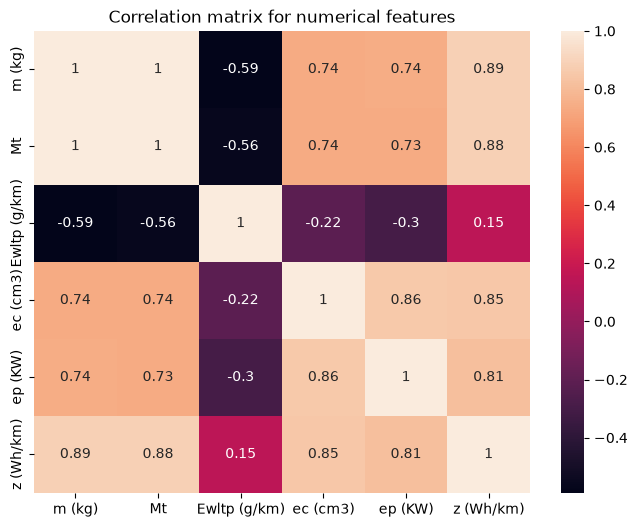

In [42]:
numeric_cols = ["m (kg)", "Mt","Ewltp (g/km)", "ec (cm3)", "ep (KW)", "z (Wh/km)"]
corr_matrix = df_fr_2024[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation matrix for numerical features")

## This looks weird, because it is a known fact that weight of a car is a factor that has an effect on the Co2 emission.  

## We know that the battery mass is huge for the electric/hybrid cars. And although the mass is increased for this type of cars, the emission is still at lowest. So it looks like we need to do our study case by case, based on the fuel type.

# let's see the numbers for different fuel types in a table:

In [43]:
# CO2, mass, and number of records by fuel type
summary_by_fuel = (
    df_fr_2024
    .groupby("Ft")
    .agg(
        n=("Ft", "size"),
        mean_Mt=("Mt", "mean"),
        median_Mt=("Mt", "median"),
        mean_CO2=("Ewltp (g/km)", "mean"),
        median_CO2=("Ewltp (g/km)", "median"),
        min_CO2=("Ewltp (g/km)", "min"),
        max_CO2=("Ewltp (g/km)", "max")
    )
    .sort_values("n", ascending=False)
)

display(summary_by_fuel)

,n,mean_Mt,median_Mt,mean_CO2,median_CO2,min_CO2,max_CO2
Ft,,,,,,,
petrol,52201,1574.10,1560.00,135.16,133.00,87.00,456.00
petrol/electric,34886,2320.83,2299.00,28.31,28.00,6.00,276.00
diesel,27803,1852.82,1797.00,144.47,140.00,106.00,322.00
diesel/electric,2983,2611.25,2576.00,13.37,11.00,10.00,52.00
e85,808,1743.09,1811.00,145.49,127.00,116.00,223.00
lpg,700,1371.39,1389.00,116.03,118.00,105.00,135.00
ng,11,1407.91,1389.00,103.36,100.00,100.00,112.00


# From this table we see that the heaviest cars actually do not have the biggest Co2 emission.
# We need to check our Mass vs. Co2 emission correlation fuel type by fuel type:

In [44]:
mt_co2_by_fuel = (
    df_fr_2024
    .groupby("Ft")
    .apply(
        lambda group: group["Mt"].corr(group["Ewltp (g/km)"])
    )
    .rename("Mt_Ewltp_corr")
    .sort_values(ascending=False)
)

display(mt_co2_by_fuel)

Ft
lpg               0.88
diesel            0.84
e85               0.78
diesel/electric   0.63
ng                0.60
petrol            0.49
petrol/electric   0.07
Name: Mt_Ewltp_corr, dtype: float64

Now we see; 
For **Diesel & LPG cars** there is a strong correlation between **Mt** and **Ewltp (g/km)** followed by **diesel/electric**

The correlation for the petrol cars still looks curious with only .22 correlation. 
This might be because of the innovative technologies applied (which we didn't include here), as well as the data distribution for fuel types in our dataset. 

Let's compare petrol and diesel cars with same number of sample sets:

Data shape: (20000, 3)

Fuel-type counts:
Ft
diesel    10000
petrol    10000
Name: count, dtype: int64


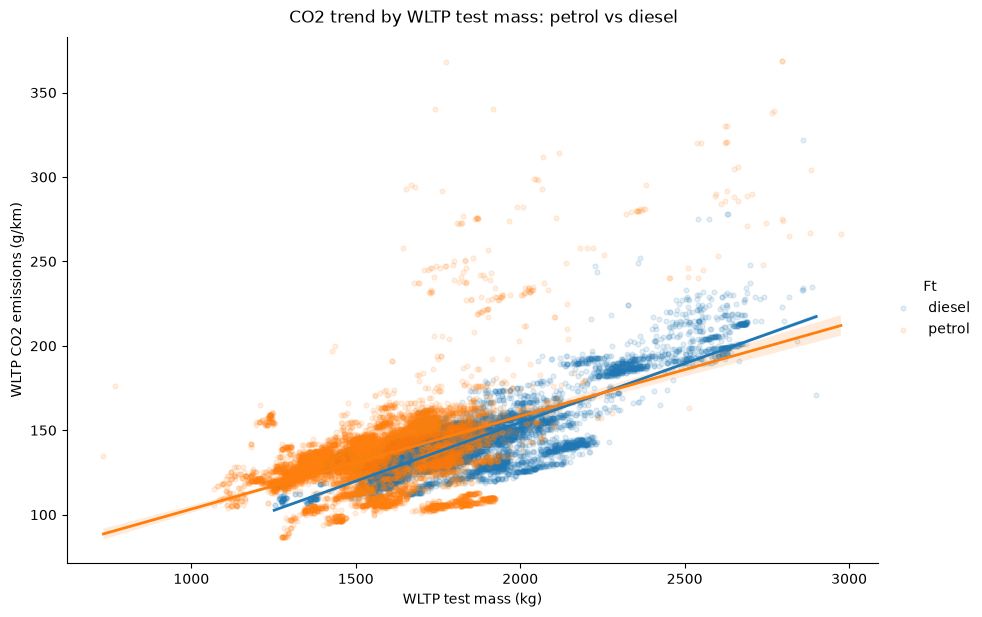

In [45]:

# Select only petrol and diesel vehicles;
# Keep the three columns needed for the chart and remove the missing rows
plot_df = df_fr_2024.loc[
    df_fr_2024["Ft"].isin(["petrol", "diesel"]),
    ["Ft", "Mt", "Ewltp (g/km)"]
].dropna().copy()

# Take an equal number (10,000) of random observations from each fuel type
plot_df = (
    plot_df
    .groupby("Ft", group_keys=False)
    .sample(n=10_000, random_state=42)
    .reset_index(drop=True)
)

# Control
print("Data shape:", plot_df.shape)
print("\nFuel-type counts:")
print(plot_df["Ft"].value_counts())

# Scatter plot + regression line for each fuel type
g = sns.lmplot(
    data=plot_df,
    x="Mt",
    y="Ewltp (g/km)",
    hue="Ft",
    scatter_kws={"alpha": 0.12, "s": 12},
    line_kws={"linewidth": 2},
    height=6,
    aspect=1.5
)

g.set_axis_labels(
    "WLTP test mass (kg)",
    "WLTP CO2 emissions (g/km)"
)

g.fig.suptitle(
    "CO2 trend by WLTP test mass: petrol vs diesel",
    y=1.02
)

plt.show()

The scatter plot confirms that the relationship between WLTP test mass and CO2 emissions differs by fuel type. Both petrol and diesel vehicles show a positive relationship, but the relationship is considerably stronger for diesel vehicles. The negative overall correlation observed earlier was caused by combining fuel groups with different mass and emission distributions

In [46]:
analysis_cols = [
    "Mt",
    "Ewltp (g/km)",
    "ec (cm3)",
    "ep (KW)"
]

corr_by_fuel = {}

for fuel_type, group in df_fr_2024.groupby("Ft"):
    corr_by_fuel[fuel_type] = group[analysis_cols].corr()

for fuel_type, matrix in corr_by_fuel.items():
    print(f"\n--- {fuel_type} ---")
    display(matrix)


--- diesel ---


,Mt,Ewltp (g/km),ec (cm3),ep (KW)
Mt,1.00,0.84,0.43,0.54
Ewltp (g/km),0.84,1.00,0.29,0.37
ec (cm3),0.43,0.29,1.00,0.76
ep (KW),0.54,0.37,0.76,1.00



--- diesel/electric ---


,Mt,Ewltp (g/km),ec (cm3),ep (KW)
Mt,1.00,0.63,0.09,0.09
Ewltp (g/km),0.63,1.00,-0.45,-0.45
ec (cm3),0.09,-0.45,1.00,1.00
ep (KW),0.09,-0.45,1.00,1.00



--- e85 ---


...

,Mt,Ewltp (g/km),ec (cm3),ep (KW)
Mt,1.00,0.60,0.77,0.92
Ewltp (g/km),0.60,1.00,0.97,0.85
ec (cm3),0.77,0.97,1.00,0.95
ep (KW),0.92,0.85,0.95,1.00



--- petrol ---


,Mt,Ewltp (g/km),ec (cm3),ep (KW)
Mt,1.00,0.49,0.60,0.52
Ewltp (g/km),0.49,1.00,0.72,0.85
ec (cm3),0.60,0.72,1.00,0.83
ep (KW),0.52,0.85,0.83,1.00



--- petrol/electric ---


,Mt,Ewltp (g/km),ec (cm3),ep (KW)
Mt,1.00,0.07,0.82,0.80
Ewltp (g/km),0.07,1.00,0.11,0.20
ec (cm3),0.82,0.11,1.00,0.90
ep (KW),0.80,0.20,0.90,1.00


In [47]:
mask = (~df_fr_2024["Ft"].isin(["petrol/electric", "diesel/electric"])) & (df_fr_2024["Electric range (km)"].isna())

# let's set these entries to 0
df_fr_2024.loc[mask, "Electric range (km)"] = 0

In [48]:
df_fr_2024["Electric range (km)"].isna().sum()

np.int64(0)

In [49]:
mask = (~df_fr_2024["Ft"].isin(["petrol/electric", "diesel/electric"])) & (df_fr_2024["z (Wh/km)"].isna())

# let's set these entries to 0
df_fr_2024.loc[mask, "z (Wh/km)"] = 0

In [50]:
df_fr_2024["z (Wh/km)"].isna().sum()

np.int64(1)

In [51]:
df_fr_2024[df_fr_2024["z (Wh/km)"].isna()]

,Tan,T,Va,Ve,Mk,Cn,m (kg),Mt,Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Erwltp (g/km),Fuel consumption,Electric range (km),r
119385,E9*KS18/858*11440*00,298,NaN,NaN,MERCEDES AMG,AMG ONE,1770.00,1835.00,224.00,petrol/electric,P,1598.00,422.00,NaN,NaN,NaN,9.90,12.00,1


Looks like this line has a lot of missing information, let's drop it.

In [52]:
df_fr_2024 = df_fr_2024.dropna(subset=["z (Wh/km)"])

Let's set the missing Erwltp (g/km) lines to 0:

In [53]:
df_fr_2024.loc[df_fr_2024["Erwltp (g/km)"].isna(), "Erwltp (g/km)"] = 0

Let's check **ec (cm3)**

In [54]:
df_fr_2024["ec (cm3)"].isna().sum()

np.int64(0)

Let's check **Fuel consumption**

In [55]:
df_fr_2024[df_fr_2024["Fuel consumption"].isna()]

,Tan,T,Va,Ve,Mk,Cn,m (kg),Mt,Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Erwltp (g/km),Fuel consumption,Electric range (km),r
10986,E1*2007/46*1783*34,AW,ABDBYA,FM6FM6DQ004G0VR24BI1AAMI,VOLKSWAGEN,POLO,1296.00,1388.00,100.00,ng,M,999.00,66.00,0.00,NaN,0.00,NaN,0.00,2
10987,E1*2007/46*1783*34,AW,ABDBYA,FM6FM6DQ004G0VR24BI1AAMI,VOLKSWAGEN,POLO,1296.00,1389.00,100.00,ng,M,999.00,66.00,0.00,NaN,0.00,NaN,0.00,2
10992,E1*2007/46*1783*35,AW,ABDBYA,FM6FM6DQ004G0VR24BI1AAMI,VOLKSWAGEN,POLO,1296.00,1389.00,100.00,ng,M,999.00,66.00,0.00,NaN,0.00,NaN,0.00,9
11019,E1*2007/46*1783*37,AW,ABDBYA,FM6FM6DQ004G0VR24BI1AAMI,VOLKSWAGEN,POLO,1296.00,1388.00,100.00,ng,M,999.00,66.00,0.00,NaN,0.00,NaN,0.00,3
11020,E1*2007/46*1783*37,AW,ABDBYA,FM6FM6DQ004G0VR24BI1AAMI,VOLKSWAGEN,POLO,1296.00,1389.00,100.00,ng,M,999.00,66.00,0.00,NaN,0.00,NaN,0.00,5
11071,E1*2007/46*1783*38,AW,ABDBYA,FM6FM6DQ004G0VR24BI1AA00,VOLKSWAGEN,POLO,1296.00,1388.00,100.00,ng,M,999.00,66.00,0.00,NaN,0.00,NaN,0.00,201
11072,E1*2007/46*1783*38,AW,ABDBYA,FM6FM6DQ004G0VR24BI1AA00,VOLKSWAGEN,POLO,1296.00,1389.00,100.00,ng,M,999.00,66.00,0.00,NaN,0.00,NaN,0.00,30
62749,E13*2007/46*1167*39,AA,ABCPGA,FM5FM5CF0104BIVR2GVW1B14M,VOLKSWAGEN,UP!,1083.00,1164.00,104.00,ng,M,999.00,50.00,0.00,NaN,0.00,NaN,0.00,4
109324,E9*2007/46*3167*25,KL,SBDHFAX0,FD7GFD7CW0054BIVL1AAB15A8M,SEAT,SEAT LEON,1409.00,1507.00,110.00,ng,M,1498.00,96.00,0.00,e9 37,0.65,NaN,0.00,5
109325,E9*2007/46*3167*25,KL,SBDHFAX0,FD7GFD7CW0054BIVL1BAB15A8T,SEAT,SEAT LEON,1432.00,1534.00,112.00,ng,M,1498.00,96.00,0.00,e9 37,0.65,NaN,0.00,1


That's interesting. All these lines have Ft = "ng" (fuel type = natural gas)
Let's see how many lines for fuel type = natural gas we have in total:

In [56]:
df_fr_2024[df_fr_2024["Ft"] == "ng"]

,Tan,T,Va,Ve,Mk,Cn,m (kg),Mt,Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Erwltp (g/km),Fuel consumption,Electric range (km),r
10986,E1*2007/46*1783*34,AW,ABDBYA,FM6FM6DQ004G0VR24BI1AAMI,VOLKSWAGEN,POLO,1296.00,1388.00,100.00,ng,M,999.00,66.00,0.00,NaN,0.00,NaN,0.00,2
10987,E1*2007/46*1783*34,AW,ABDBYA,FM6FM6DQ004G0VR24BI1AAMI,VOLKSWAGEN,POLO,1296.00,1389.00,100.00,ng,M,999.00,66.00,0.00,NaN,0.00,NaN,0.00,2
10992,E1*2007/46*1783*35,AW,ABDBYA,FM6FM6DQ004G0VR24BI1AAMI,VOLKSWAGEN,POLO,1296.00,1389.00,100.00,ng,M,999.00,66.00,0.00,NaN,0.00,NaN,0.00,9
11019,E1*2007/46*1783*37,AW,ABDBYA,FM6FM6DQ004G0VR24BI1AAMI,VOLKSWAGEN,POLO,1296.00,1388.00,100.00,ng,M,999.00,66.00,0.00,NaN,0.00,NaN,0.00,3
11020,E1*2007/46*1783*37,AW,ABDBYA,FM6FM6DQ004G0VR24BI1AAMI,VOLKSWAGEN,POLO,1296.00,1389.00,100.00,ng,M,999.00,66.00,0.00,NaN,0.00,NaN,0.00,5
11071,E1*2007/46*1783*38,AW,ABDBYA,FM6FM6DQ004G0VR24BI1AA00,VOLKSWAGEN,POLO,1296.00,1388.00,100.00,ng,M,999.00,66.00,0.00,NaN,0.00,NaN,0.00,201
11072,E1*2007/46*1783*38,AW,ABDBYA,FM6FM6DQ004G0VR24BI1AA00,VOLKSWAGEN,POLO,1296.00,1389.00,100.00,ng,M,999.00,66.00,0.00,NaN,0.00,NaN,0.00,30
62749,E13*2007/46*1167*39,AA,ABCPGA,FM5FM5CF0104BIVR2GVW1B14M,VOLKSWAGEN,UP!,1083.00,1164.00,104.00,ng,M,999.00,50.00,0.00,NaN,0.00,NaN,0.00,4
109324,E9*2007/46*3167*25,KL,SBDHFAX0,FD7GFD7CW0054BIVL1AAB15A8M,SEAT,SEAT LEON,1409.00,1507.00,110.00,ng,M,1498.00,96.00,0.00,e9 37,0.65,NaN,0.00,5
109325,E9*2007/46*3167*25,KL,SBDHFAX0,FD7GFD7CW0054BIVL1BAB15A8T,SEAT,SEAT LEON,1432.00,1534.00,112.00,ng,M,1498.00,96.00,0.00,e9 37,0.65,NaN,0.00,1


Those are the same 11 lines. Looks like Fuel consumption is completely missing for fuel type = ng.

Let's see the overall percentage of fuel type = ng

In [57]:
ft_pct = (
    df_fr_2024["Ft"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)
ft_pct.columns = ["Ft", "percentage"]
print(ft_pct)

                Ft  percentage
0           petrol       43.72
1  petrol/electric       29.22
2           diesel       23.29
3  diesel/electric        2.50
4              e85        0.68
5              lpg        0.59
6               ng        0.01


That number is really low (0.01%). Let's remove it from our dataset.

In [58]:
df_fr_2024 = df_fr_2024.dropna(subset=["Fuel consumption"])

Let's check all our missing values one more time:

In [59]:
df_fr_2024.isna().sum()

Tan                        0
T                          0
Va                         0
Ve                         1
Mk                         0
Cn                         0
m (kg)                     0
Mt                         0
Ewltp (g/km)               0
Ft                         0
Fm                         0
ec (cm3)                   0
ep (KW)                    0
z (Wh/km)                  0
IT                     58621
Erwltp (g/km)              0
Fuel consumption           0
Electric range (km)        0
r                          0
dtype: int64

We have **1** line with missing Version; let's see what it is:

In [60]:
df_fr_2024[df_fr_2024["Ve"].isna()]

,Tan,T,Va,Ve,Mk,Cn,m (kg),Mt,Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Erwltp (g/km),Fuel consumption,Electric range (km),r
59488,E1*KS18/858*00010*01,X-BOW,1,NaN,KTM,X-BOW GT-XR,1250.00,1371.00,214.00,petrol,M,2480.00,368.00,0.00,NaN,0.00,9.10,0.00,1


Let's see if there are multiple cars with the same model so that the version matters:

In [61]:
df_fr_2024[df_fr_2024["Cn"] == "X-BOW GT-XR"]

,Tan,T,Va,Ve,Mk,Cn,m (kg),Mt,Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Erwltp (g/km),Fuel consumption,Electric range (km),r
59488,E1*KS18/858*00010*01,X-BOW,1,NaN,KTM,X-BOW GT-XR,1250.00,1371.00,214.00,petrol,M,2480.00,368.00,0.00,NaN,0.00,9.10,0.00,1


That's nice, there's only 1 entry for this model, so the missing version won't make any confusion. We can leave it as it is. 

# Another important thing on the correlation graph:
**"m (kg)"** & **"Mt"** columns are %100 correlated. This is no surprise becasue **Mt** column is test mass, which is **M (kg)** + Optional Equipment mass + Payload.


## In order to avoid Multicollinearity we must drop one of these columns. 
We could create a new column to keep their difference **Mt - m (kg)**, so that we could train our models with the amount of **Weight of Additional Equipment and Options** as an independent piece of information; but Linear models or Artificial Neural Networks (ANN) solve this subtraction relationship between Mt and Equipment_Mass very quickly and flawlessly reconstruct the value of **m (kg)** in the background. So, what happens if **m (kg)** is reconstructed? **There is a risk of significant target leakage.**

Futhermore; In WLTP emissions testing, vehicles are connected to a dynamometer in the laboratory based directly on the **Mt** (Test Mass) value, and CO2 emissions are calculated directly based on this weight. In other words, **Mt** is a regulatory/laboratory-based input that directly determines emissions. If we want to estimate the emissions of a brand-new car fresh off the assembly line in the future (for example, in 2026), we would not have the **Mt** (Test Mass) value because the car has not yet undergone official laboratory testing. We will only have the curb weight **m, (kg)** listed in the car’s catalog.

So we keep **m (kg)** column and drop the **Mt** column.

In [62]:
# We can now drop the "Mt" column
df_fr_2024 = df_fr_2024.drop(columns = ['Mt'])

## Next:We also have 58621 lines where **IT** column has a missing value. 
Let's check if the corresponding **Erwltp (g/km)** column has **0** for these lines:

In [63]:
len(df_fr_2024[(df_fr_2024["IT"].isna()) & (df_fr_2024["Erwltp (g/km)"] == 0)])

58621

That's the same number as the missing lines. So the data is consistent.
Let's replace the missing values with **"none"**

In [64]:
df_fr_2024.loc[df_fr_2024["IT"].isna(), "IT"] = "none"

Let's merge **"Mk", "Cn", "Va", "Ve", "T", "Tan"** as a new column named **"Vehicle"**

In [65]:
# Columns to be merged
cols_to_merge = ["Mk", "Cn", "Va", "Ve", "T", "Tan"]

df_fr_2024["Vehicle"] = df_fr_2024[cols_to_merge].apply(
    lambda x: " - ".join(x.dropna().astype(str)), axis=1
)
df_fr_2024.head()

# Let's move Vehicle column to the front
col_to_front = "Vehicle"

# List the remaining columns (excluding "Vehicle")
cols_remaining = [col for col in df_fr_2024.columns if col != col_to_front]

# Create a DataFrame with the new order
df_fr_2024 = df_fr_2024[[col_to_front] + cols_remaining]

df_fr_2024.head()

,Vehicle,Tan,T,Va,Ve,Mk,Cn,m (kg),Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Erwltp (g/km),Fuel consumption,Electric range (km),r
0,VOLKSWAGEN - TOURAN - DTSBAF - FD7FD7GC0044BIS...,E1*2001/116*0211*63,1T,DTSBAF,FD7FD7GC0044BIS72VR21BAI0,VOLKSWAGEN,TOURAN,1675.00,140.00,diesel,M,1968.00,110.00,0.00,e13 29,1.00,5.30,0.00,3
1,VOLKSWAGEN - TOURAN - DTRCAF - FM6FM6C90044BIS...,E1*2001/116*0211*65,1T,DTRCAF,FM6FM6C90044BIS71VR21BAI0,VOLKSWAGEN,TOURAN,1632.00,134.00,diesel,M,1968.00,90.00,0.00,e13 29,1.00,5.10,0.00,1
2,VOLKSWAGEN - TOURAN - DTSBAC - FD7FD7GC0044BIS...,E1*2001/116*0211*65,1T,DTSBAC,FD7FD7GC0044BIS50VR21AAI0,VOLKSWAGEN,TOURAN,1631.00,137.00,diesel,M,1968.00,110.00,0.00,e13 29,1.00,5.20,0.00,1
3,VOLKSWAGEN - TOURAN - DTSBAC - FD7FD7GC0044BIS...,E1*2001/116*0211*65,1T,DTSBAC,FD7FD7GC0044BIS50VR21AAIM,VOLKSWAGEN,TOURAN,1631.00,137.00,diesel,M,1968.00,110.00,0.00,e13 28 29,1.68,5.20,0.00,1
4,VOLKSWAGEN - TOURAN - DTSBAF - FD7FD7GC0044BIS...,E1*2001/116*0211*65,1T,DTSBAF,FD7FD7GC0044BIS71VR21BAI0,VOLKSWAGEN,TOURAN,1675.00,140.00,diesel,M,1968.00,110.00,0.00,e13 29,1.00,5.30,0.00,1


In [66]:
# "Fuel consumption", "Erwltp (g/km)" will be dropped in preprocessing notebook.
# let's drop the old columns
cols_to_drop = ["Mk", "Cn", "Va", "Ve", "T", "Tan"]              
df_fr_2024 = df_fr_2024.drop(columns = cols_to_drop, errors="ignore")
df_fr_2024.head()

,Vehicle,m (kg),Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Erwltp (g/km),Fuel consumption,Electric range (km),r
0,VOLKSWAGEN - TOURAN - DTSBAF - FD7FD7GC0044BIS...,1675.00,140.00,diesel,M,1968.00,110.00,0.00,e13 29,1.00,5.30,0.00,3
1,VOLKSWAGEN - TOURAN - DTRCAF - FM6FM6C90044BIS...,1632.00,134.00,diesel,M,1968.00,90.00,0.00,e13 29,1.00,5.10,0.00,1
2,VOLKSWAGEN - TOURAN - DTSBAC - FD7FD7GC0044BIS...,1631.00,137.00,diesel,M,1968.00,110.00,0.00,e13 29,1.00,5.20,0.00,1
3,VOLKSWAGEN - TOURAN - DTSBAC - FD7FD7GC0044BIS...,1631.00,137.00,diesel,M,1968.00,110.00,0.00,e13 28 29,1.68,5.20,0.00,1
4,VOLKSWAGEN - TOURAN - DTSBAF - FD7FD7GC0044BIS...,1675.00,140.00,diesel,M,1968.00,110.00,0.00,e13 29,1.00,5.30,0.00,1


# Let's decode the **IT** column:

In [67]:
def get_unique_it_values(df, column="IT"):
    unique_values = set()

    for value in df[column].dropna():
        unique_values.update(str(value).split())

    return list(unique_values)

unique_it_values = get_unique_it_values(df_fr_2024, "IT")

print("All unique components of IT values:\n", unique_it_values)

All unique components of IT values:
 ['e2', '28', 'e19', 'e9', 'none', 'e8', '29', 'e3', '32', '37', 'e1', 'e4', '33', 'e5', 'e24', 'e6', 'e13']


### With a bit of investgation, we find out that the entries start with letter "e" in the **IT** string corresponds to the Approving Authority, which is the country that authorised that technology. 

For example; 
- **e1**: Germany,
- **e2**: France,
- **e3**: Italy,
- **e4**: the Netherlands,
- **e13**: Luxembourg,
- **e24**: Ireland.

This doesn't contribute to our study for Co2 emission prediction study, **so we will omit this part of the data.**

### The following numbers divided by a space, each correspond to an innovative technology.
For example;
- **28**: 12V high-efficiency alternator technology ((High-efficiency generators that reduce emissions, developed by Valeo, Denso, or Mitsubishi).
- **29**: Energy-efficient LED lighting technology for vehicle lighting. ((LED systems that save energy in headlights and taillights).

Let's make a dictionary of the values for the different innovative technologies:

In [68]:
it_labels = {
    'IT_28': 'Efficient 12V Alternator',
    'IT_29': 'Efficient LED Lighting',
    'IT_32': 'Thermal Insulation Glass / Solar Roof',
    'IT_33': 'Active Grille Shutter / Engine Compartment Encapsulation',
    'IT_37': '48V Motor-Generator / Mild-Hybrid Systems',
    'IT_none': 'No Eco-Innovation Technology'
}
df_it_labels = pd.DataFrame(list(it_labels.items()), columns=["IT_Code", "IT_Description"])

pd.set_option("display.max_colwidth", None)

display(df_it_labels)

,IT_Code,IT_Description
0,IT_28,Efficient 12V Alternator
1,IT_29,Efficient LED Lighting
2,IT_32,Thermal Insulation Glass / Solar Roof
3,IT_33,Active Grille Shutter / Engine Compartment Encapsulation
4,IT_37,48V Motor-Generator / Mild-Hybrid Systems
5,IT_none,No Eco-Innovation Technology


In [69]:
# let's export this into our references
df_it_labels.to_csv("../references/data_dictionaries/eu/Column-definition-IT-2024-FR.csv", index = False)

# Now, let's decode and then encode the **IT** column:

In [70]:
import re
# ----------------------------------------------------
# Decoding IT column
# ----------------------------------------------------
# Filters out numbers AND the word "none"
# This regex matches both pure numbers (\b\d+\b) and the word "none."
# It also completely filters out country codes such as e1 and e13.
df_fr_2024['tech_list'] = df_fr_2024['IT'].apply(lambda x: re.findall(r'\b\d+\b|\bnone\b', str(x).lower()))

# ----------------------------------------------------
# One-Hot Encoding IT Column
# ----------------------------------------------------
tech_dummies = df_fr_2024['tech_list'].str.join('|').str.get_dummies().add_prefix('IT_')

# We combine the original dataset with emerging technologies
df_fr_2024 = pd.concat([df_fr_2024, tech_dummies], axis=1)

print("CLEANED & ENCODED DATASET:")
df_fr_2024.drop(["IT", "tech_list"], inplace = True, axis = 1)
display(df_fr_2024.head())



CLEANED & ENCODED DATASET:


,Vehicle,m (kg),Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),Erwltp (g/km),Fuel consumption,Electric range (km),r,IT_28,IT_29,IT_32,IT_33,IT_37,IT_none
0,VOLKSWAGEN - TOURAN - DTSBAF - FD7FD7GC0044BIS72VR21BAI0 - 1T - E1*2001/116*0211*63,1675.00,140.00,diesel,M,1968.00,110.00,0.00,1.00,5.30,0.00,3,0,1,0,0,0,0
1,VOLKSWAGEN - TOURAN - DTRCAF - FM6FM6C90044BIS71VR21BAI0 - 1T - E1*2001/116*0211*65,1632.00,134.00,diesel,M,1968.00,90.00,0.00,1.00,5.10,0.00,1,0,1,0,0,0,0
2,VOLKSWAGEN - TOURAN - DTSBAC - FD7FD7GC0044BIS50VR21AAI0 - 1T - E1*2001/116*0211*65,1631.00,137.00,diesel,M,1968.00,110.00,0.00,1.00,5.20,0.00,1,0,1,0,0,0,0
3,VOLKSWAGEN - TOURAN - DTSBAC - FD7FD7GC0044BIS50VR21AAIM - 1T - E1*2001/116*0211*65,1631.00,137.00,diesel,M,1968.00,110.00,0.00,1.68,5.20,0.00,1,1,1,0,0,0,0
4,VOLKSWAGEN - TOURAN - DTSBAF - FD7FD7GC0044BIS71VR21BAI0 - 1T - E1*2001/116*0211*65,1675.00,140.00,diesel,M,1968.00,110.00,0.00,1.00,5.30,0.00,1,0,1,0,0,0,0


# After dropping all these columns, and cleaning the data, let's export our dataset into data/processed/EU directory as csv now:

In [71]:
df_fr_2024.to_csv("../data/processed/EU/2024_FR_cleaned.csv", index = False)
df_fr_2024_cleaned = pd.read_csv("../data/processed/EU/2024_FR_cleaned.csv")

df_fr_2024_cleaned.head()

,Vehicle,m (kg),Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),Erwltp (g/km),Fuel consumption,Electric range (km),r,IT_28,IT_29,IT_32,IT_33,IT_37,IT_none
0,VOLKSWAGEN - TOURAN - DTSBAF - FD7FD7GC0044BIS72VR21BAI0 - 1T - E1*2001/116*0211*63,1675.00,140.00,diesel,M,1968.00,110.00,0.00,1.00,5.30,0.00,3,0,1,0,0,0,0
1,VOLKSWAGEN - TOURAN - DTRCAF - FM6FM6C90044BIS71VR21BAI0 - 1T - E1*2001/116*0211*65,1632.00,134.00,diesel,M,1968.00,90.00,0.00,1.00,5.10,0.00,1,0,1,0,0,0,0
2,VOLKSWAGEN - TOURAN - DTSBAC - FD7FD7GC0044BIS50VR21AAI0 - 1T - E1*2001/116*0211*65,1631.00,137.00,diesel,M,1968.00,110.00,0.00,1.00,5.20,0.00,1,0,1,0,0,0,0
3,VOLKSWAGEN - TOURAN - DTSBAC - FD7FD7GC0044BIS50VR21AAIM - 1T - E1*2001/116*0211*65,1631.00,137.00,diesel,M,1968.00,110.00,0.00,1.68,5.20,0.00,1,1,1,0,0,0,0
4,VOLKSWAGEN - TOURAN - DTSBAF - FD7FD7GC0044BIS71VR21BAI0 - 1T - E1*2001/116*0211*65,1675.00,140.00,diesel,M,1968.00,110.00,0.00,1.00,5.30,0.00,1,0,1,0,0,0,0


# Summary:
- Country,
- Status,
- De,
- Vf,
- Enedc (g/km),
- ech,
- MMS,
- Ernedc (g/km),
- "VFN",
- "Mp",
- "Mh",
- "Man",
- "Tan"
- "Mt"
- "T"
- "Va"
- "Ve"
- "RLFI",
- "Cr",
- "Ct",
- "Erwltp"
- "Fuel consumption"
- "Date of registration",
- "ID"  
Columns have been dropped. 

- **electric vehicles & hydrogen vehicles** have been filtered out since they don't have Co2 emission.
- duplicate lines have been merged, occurance counts kept in **"r"** column.
- Fuel Type = ng data has been removed due to very low presentation (0.01%) & completely missing fuel consumption data.
- Missing **"Electric range (km)"**, **"z (Wh/km)"** values have been set to **"0"**
- **IT** column has been decoded, one-hot encoded.
- Merged Mk - Cn - Va - Ve - T - Tan columns as Vehicle column.

# What to do next:
- check the distributions of numerical columns and decide to normalize/standardize
- study the correlations
- separate train and test base
- encode Ft, Fm columns
- etc

# Notes
- we have an outlier where m(kg) = 570 kg.